In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Infomacion del drive

In [ ]:
import pandas as pd
ruta_nivel_rio = '/content/drive/MyDrive/Datos Tesis/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
archivo_csv = '/content/drive/MyDrive/Datos Tesis/datosClima/datos_promedios_mensuales_clima.csv'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClima = pd.read_csv(archivo_csv)
# Leer el archivo Excel y cargar la pestaña en un DataFrame
FreatimetrosImputados = pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_2010_2023 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)


In [ ]:
FreatimetrosImputados['fecha'] = pd.to_datetime(FreatimetrosImputados['Date'])
nivelRioNegro_mensual_2010_2023['fecha'] = pd.to_datetime(nivelRioNegro_mensual_2010_2023['Date'])
datosClima['Date'] = pd.to_datetime(datosClima['Date'])
# Filtrar datos para el DataFrame DF
filtro_DF = (FreatimetrosImputados['fecha'].dt.year >= 2010) & (FreatimetrosImputados['fecha'].dt.year <= 2023) & (FreatimetrosImputados['fecha'].dt.month.isin([9,10,11,12,1,2,3,4]))
freatimetros_caso2 = FreatimetrosImputados[filtro_DF]

# Filtrar datos para el DataFrame promediosAlturaRoca_df
filtro_promedios = (nivelRioNegro_mensual_2010_2023['fecha'].dt.year >= 2010) & (nivelRioNegro_mensual_2010_2023['fecha'].dt.year <= 2023) & (nivelRioNegro_mensual_2010_2023['fecha'].dt.month.isin([9,10,11,12,1,2,3,4]))
nivelRioNegro_caso2 = nivelRioNegro_mensual_2010_2023[filtro_promedios]


filtro_datosClima_caso2 =(datosClima['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
datosClima_caso2 = datosClima[filtro_datosClima_caso2]
# Mostrar los datos filtrados


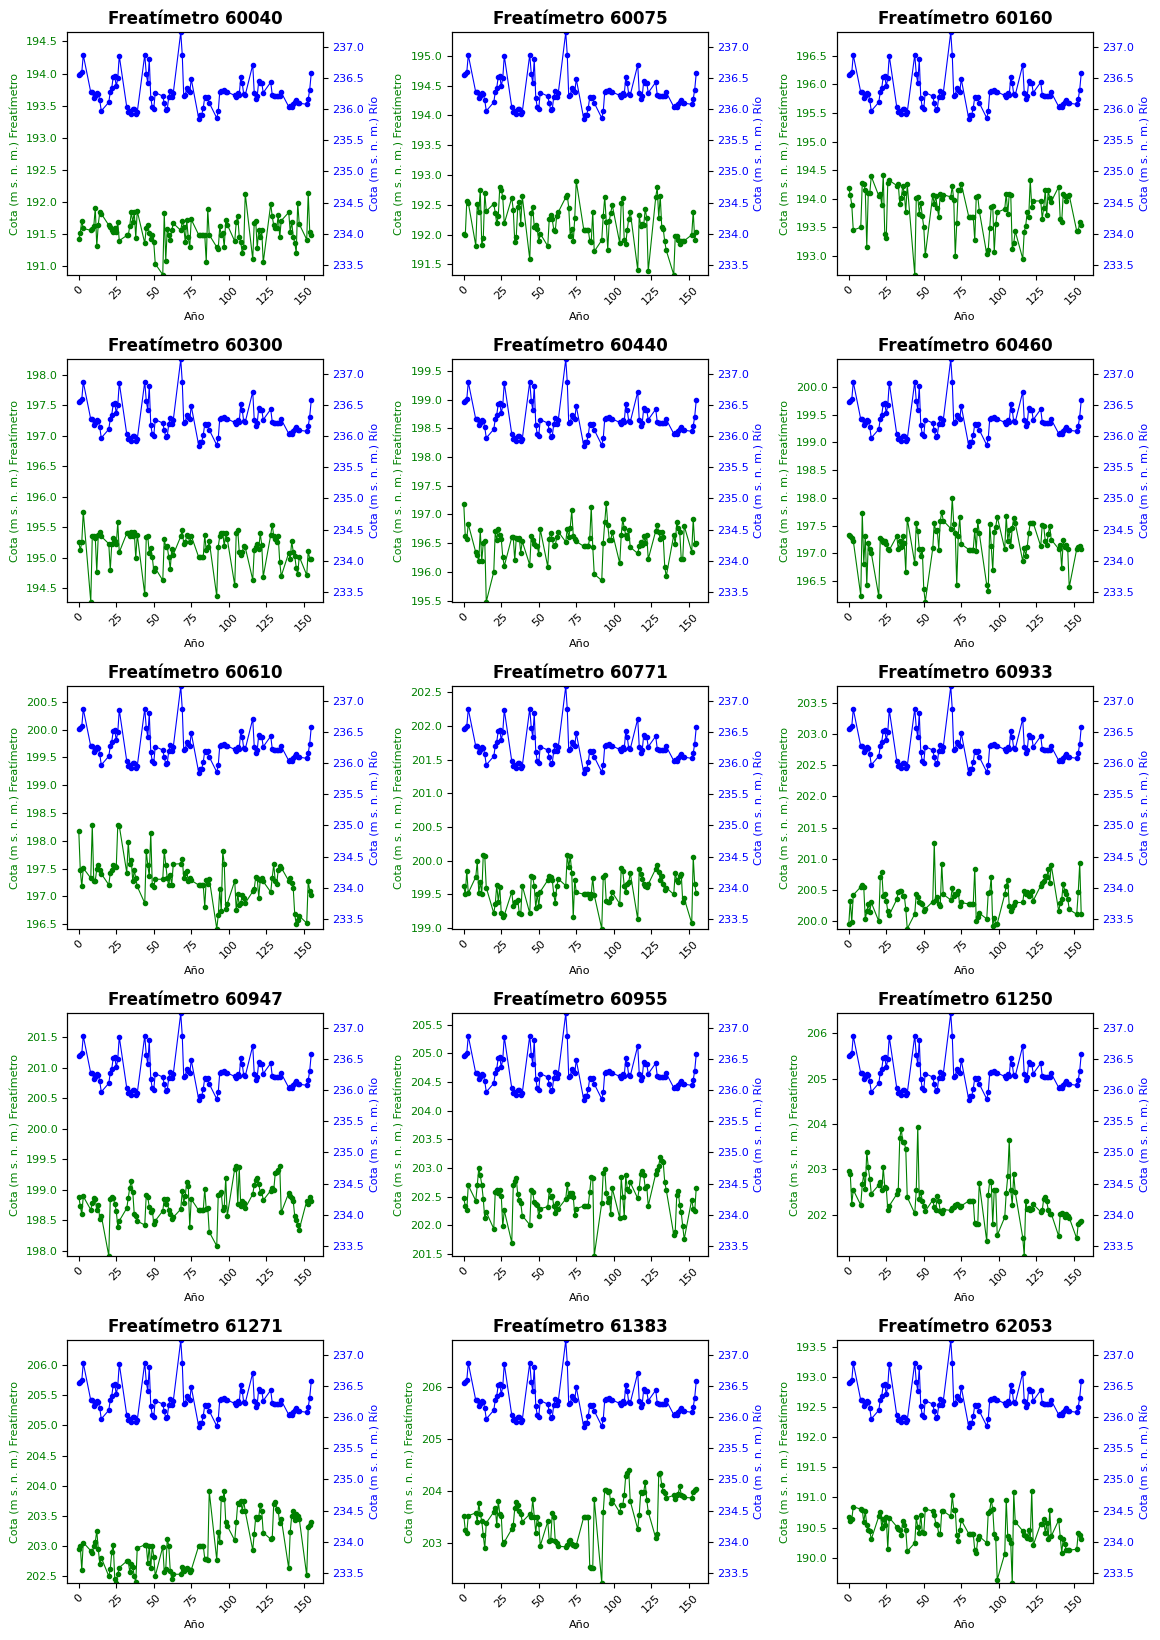

In [ ]:
import matplotlib.pyplot as plt

# Lista de freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Número de filas y columnas para los subplots
n_rows = 5
n_cols = 3

# Crear la figura y los ejes con subplots
fig, axs = plt.subplots(n_rows, n_cols, figsize=(11.7, 16.5))  # A4 (11.7 x 16.5 pulgadas)



# Iterar sobre cada freatímetro y generar gráficos individuales en cada subplot
for i, freatimetro in enumerate(freatimetros):
    # Definir fila y columna del subplot actual
    row = i // n_cols
    col = i % n_cols

    # Obtener el subplot actual
    ax1 = axs[row, col]

    # Freatímetro actual
    freatimetro_data = freatimetros_caso2[freatimetro]

    # Dibujar la gráfica del freatímetro con líneas más finas y puntos más pequeños
    ax1.plot(freatimetro_data, marker='o', markersize=3, linestyle='-', linewidth=0.8, color='green', label=f'Freatímetro {freatimetro}')
    ax1.set_xlabel('Año', fontsize=8)
    ax1.set_ylabel('Cota (m s. n. m.) Freatímetro', color='green', fontsize=8)
    ax1.tick_params(axis='y', labelcolor='green', labelsize=8)

    # Dibujar el gráfico lineal para el promedio del río
    ax2 = ax1.twinx()
    ax2.plot(nivelRioNegro_caso2['promedio'], marker='o', markersize=3, linestyle='-', linewidth=0.8, color='blue', label='Promedio de Altura río')
    ax2.set_ylabel('Cota (m s. n. m.) Río', color='blue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=8)

    # Ajustar los límites del eje y
    buffer = 2.5  # Espacio entre los gráficos
    ax1.set_ylim([freatimetro_data.min(), freatimetro_data.max() + buffer])
    ax2.set_ylim([nivelRioNegro_caso2['promedio'].min() - buffer, nivelRioNegro_caso2['promedio'].max()])

    # Ajustar el tamaño y la rotación de las etiquetas del eje x
    ax1.tick_params(axis='x', labelsize=8, rotation=45)  # Tamaño y rotación del texto en el eje x

    # Añadir título a cada subplot
    ax1.set_title(f'Freatímetro {freatimetro}', fontsize=12, fontweight='bold')


# Ajustar el diseño de la figura
fig.tight_layout()

# Mostrar el gráfico
plt.show()


In [ ]:
import pandas as pd


datosClima = datosClima_caso2.rename(columns={'Date': 'fecha'})
# Asegurar que las columnas 'fecha' de todos los DataFrames estén en formato datetime
datosClima['fecha'] = pd.to_datetime(datosClima['fecha'])
freatimetros_caso2['fecha'] = pd.to_datetime(freatimetros_caso2['fecha'])
nivelRioNegro_caso2['fecha'] = pd.to_datetime(nivelRioNegro_caso2['fecha'])

# Crear columnas de 'año-mes' para los DataFrames
datosClima['año_mes'] = datosClima['fecha'].dt.to_period('M')
freatimetros_caso2['año_mes'] = freatimetros_caso2['fecha'].dt.to_period('M')
nivelRioNegro_caso2['año_mes'] = nivelRioNegro_caso2['fecha'].dt.to_period('M')

# Unir datosClima y datos_filtrados_DF usando 'año_mes' como clave
df_merged = pd.merge(datosClima, freatimetros_caso2, on='año_mes', how='inner')

# Luego, unir con datos_filtrados_promedios también usando 'año_mes' como clave
df_merged_final = pd.merge(df_merged, nivelRioNegro_caso2, on='año_mes', how='inner')

# Renombrar la columna 'promedio' a 'nivelRio'
df_merged_final = df_merged_final.rename(columns={'promedio': 'nivelRio'})
# Reordenar las columnas para que 'nivelRio' esté en la primera posición
cols = ['nivelRio'] + [col for col in df_merged_final.columns if col != 'nivelRio']
df_merged_final = df_merged_final[cols]

df_merged_final = df_merged_final.drop(columns=['index'])
df_merged_final = df_merged_final.drop(columns=['año_mes'])
#df_merged_final = df_merged_final.drop(columns=['fecha'])
df_merged_final = df_merged_final.drop(columns=['fecha_x'])
df_merged_final = df_merged_final.drop(columns=['fecha_y'])
df_merged_final = df_merged_final.drop(columns=['año'])
df_merged_final = df_merged_final.drop(columns=['mes'])
df_merged_final.to_excel('/content/drive/MyDrive/Datos Tesis/datasetRedNcaso2.xlsx')
# Mostrar las primeras filas para verificar la unión
print(df_merged_final.head)

<ipython-input-5-e79216c92340>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freatimetros_caso2['fecha'] = pd.to_datetime(freatimetros_caso2['fecha'])
<ipython-input-5-e79216c92340>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nivelRioNegro_caso2['fecha'] = pd.to_datetime(nivelRioNegro_caso2['fecha'])
<ipython-input-5-e79216c92340>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

<bound method NDFrame.head of       nivelRio   Temp Out    Hi Temp   Low Temp    Out Hum   Dew Pt.  \
0   236.547742  15.532369  15.707670  15.357260  51.051134  3.838688   
1   236.556429  13.979232  14.164694  13.796521  54.516615  3.505192   
2   236.584839  16.249733  16.422186  16.075099  55.321884  6.083175   
3   236.864667  12.937151  13.085438  12.785879  58.804169  3.916524   
4   236.268333  12.763769  12.929717  12.597198  51.613506  1.567696   
..         ...        ...        ...        ...        ...       ...   
75  236.224333  13.540648  13.719294  13.365239  65.053237  5.956784   
76  236.708000  12.114784  12.283863  11.948933  61.575221  3.506715   
77  236.260323  11.982407  12.145602  11.816512  63.270062  4.083102   
78  236.163333  12.371682  12.536420  12.207793  64.993056  4.813272   
79  236.205484  13.283333  13.440664  13.127006  63.064815  4.984028   

    Wind Speed  Wind Run   Hi Speed       Bar    ...   60610       60771  \
0     2.445683  0.408693   7.

CORRELACIONES

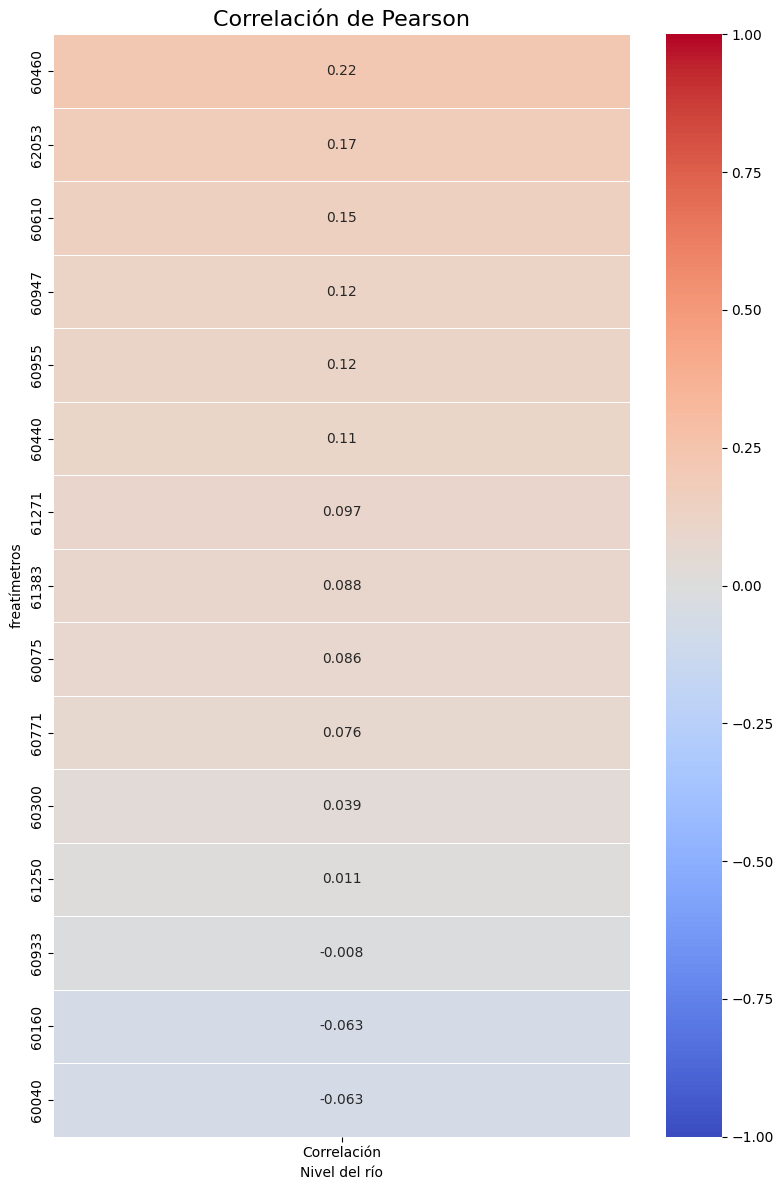

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Pearson
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = nivelRioNegro_caso2['promedio']

# Calcular la correlación de Pearson entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación de Pearson
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': freatimetros_caso2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Asegurarse de eliminar filas con NaNs

    # Calcular la correlación de Pearson
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = pearsonr(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Pearson', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()

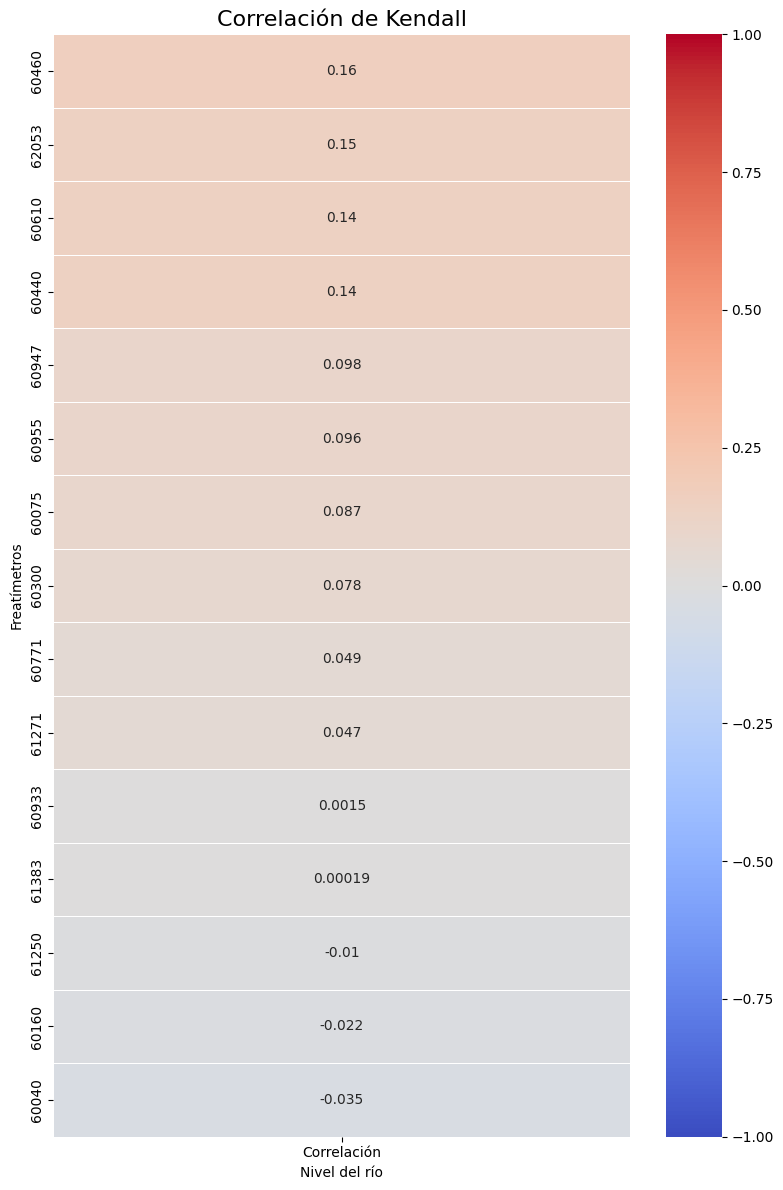

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau  # Cambiamos pearsonr por kendalltau

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Kendall
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = nivelRioNegro_caso2['promedio']

# Calcular la correlación de Kendall entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': freatimetros_caso2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Eliminar filas con NaNs

    # Calcular la correlación de Kendall
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = kendalltau(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Kendall', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('Freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()


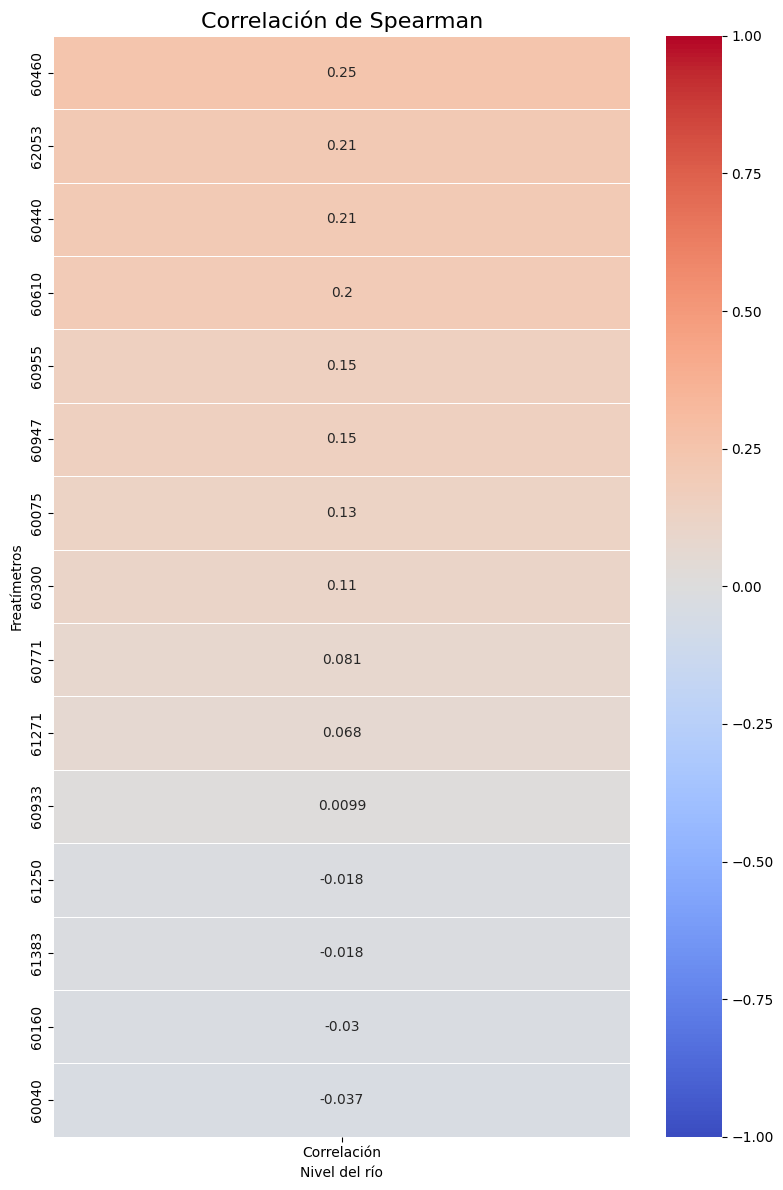

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr  # Cambiamos a spearmanr

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Spearman
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = nivelRioNegro_caso2['promedio']

# Calcular la correlación de Spearman entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': freatimetros_caso2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Eliminar filas con NaNs

    # Calcular la correlación de Spearman
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = spearmanr(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Spearman', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('Freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
ruta ='/content/drive/MyDrive/Datos Tesis/df_merged_freatimetros_nivelRioNegro_long.xlsx'#este arechivo esta en formato long listo para entrenar una red neuronal
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
df_merged_freatimetros_nivelRioNegro_long = pd.read_excel(ruta, sheet_name=nombre_pestaña)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ========================================================================
# 1️⃣ **Preprocesamiento: Codificación y Normalización**
# ========================================================================
df = df_merged_freatimetros_nivelRioNegro_long.copy()

# 🔹 **Codificación del ID de freatímetros**
label_encoder = LabelEncoder()
df['freátimetro_id_encoded'] = label_encoder.fit_transform(df['freátimetro_id'])

# 🔹 **Escalar el nivel del río**
scaler_X = StandardScaler()
df['nivelRio_scaled'] = scaler_X.fit_transform(df[['nivelRio']])

# 🔹 **Escalar el nivel freático**
scaler_y = StandardScaler()
df['nivel_freatico_scaled'] = scaler_y.fit_transform(df[['nivel_freatico']])


# ========================================================================
# 2️⃣ **Generación de Secuencias**
# ========================================================================
def create_sequences_per_freatimetro(df, window_size=8):
    """
    Genera secuencias por cada freatímetro sin mezclar datos entre ellos.
    Retorna:
    - X_seq: Matriz (n_muestras, window_size, n_features)
    - y_seq: Valores objetivo correspondientes
    - freatimetros_seq: Lista con los freatímetros correspondientes
    - fechas_seq: Lista con las fechas correspondientes a cada secuencia
    """
    X_seq, y_seq, freatimetros_seq, fechas_seq = [], [], [], []

    for freatimetro_id in df['freátimetro_id_encoded'].unique():
        df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

        X = df_freatimetro[['nivelRio_scaled', 'freátimetro_id_encoded']].values
        y = df_freatimetro['nivel_freatico_scaled'].values
        fechas = df_freatimetro['fecha'].values


        for i in range(len(X) - window_size):
            ventana_X = X[i:i + window_size]
            valor_y = y[i + window_size]
            fecha_prediccion = fechas[i + window_size]
            X_seq.append(ventana_X)
            y_seq.append(valor_y)
            freatimetros_seq.append(freatimetro_id)
            fechas_seq.append(fecha_prediccion)

    return np.array(X_seq), np.array(y_seq), np.array(freatimetros_seq), np.array(fechas_seq)

# 🔹 **Generar secuencias**
X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df, window_size=8)

# ========================================================================
# 3️⃣ **Generar Secuencias por Freatímetro**
# ========================================================================
X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
freatimetros_train_list, freatimetros_test_list = [], []
fechas_train_list, fechas_test_list = [], []

for freatimetro_id in df['freátimetro_id_encoded'].unique():
    df_freatimetro = df[df['freátimetro_id_encoded'] == freatimetro_id].sort_values('fecha')

    # 🔹 Generar secuencias para este freatímetro
    X_seq, y_seq, freatimetros_seq, fechas_seq = create_sequences_per_freatimetro(df_freatimetro, window_size=8)

    # 🔹 Dividir en entrenamiento y prueba SOLO para este freatímetro
    train_size = int(len(X_seq) * 0.8)

    X_train_list.append(X_seq[:train_size])
    X_test_list.append(X_seq[train_size:])
    y_train_list.append(y_seq[:train_size])
    y_test_list.append(y_seq[train_size:])
    fechas_train_list.append(fechas_seq[:train_size])
    fechas_test_list.append(fechas_seq[train_size:])
    freatimetros_train_list.append(freatimetros_seq[:train_size])
    freatimetros_test_list.append(freatimetros_seq[train_size:])

# 🔹 Concatenar las listas finales para obtener los conjuntos balanceados
X_train, X_test = np.vstack(X_train_list), np.vstack(X_test_list)
y_train, y_test = np.hstack(y_train_list), np.hstack(y_test_list)
fechas_train, fechas_test = np.hstack(fechas_train_list), np.hstack(fechas_test_list)
freatimetros_train, freatimetros_test = np.hstack(freatimetros_train_list), np.hstack(freatimetros_test_list)




NameError: name 'df_merged_freatimetros_nivelRioNegro_long' is not defined

In [ ]:
# ========================================================================
# 4️⃣ **Definir y Entrenar el Modelo LSTM**
# ========================================================================
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='tanh', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

# 🔹 **Compilar el Modelo**
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 🔹 **Entrenar con Early Stopping**
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2, verbose=1, callbacks=[early_stop])


Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.4433 - mae: 0.5188 - val_loss: 2.4411 - val_mae: 1.2222
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0911 - mae: 0.2350 - val_loss: 3.5156 - val_mae: 1.1531
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0849 - mae: 0.2259 - val_loss: 3.1375 - val_mae: 1.1121
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0638 - mae: 0.1968 - val_loss: 3.3444 - val_mae: 1.1100
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0694 - mae: 0.2066 - val_loss: 3.0541 - val_mae: 1.1421
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0598 - mae: 0.1899 - val_loss: 3.7867 - val_mae: 1.2271
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0622 - mae: 0.1971 - val_loss: 3.3509 - val_mae: 1.1144
Epoch 8/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0645 - mae: 0.1989 - val_loss: 3.5494 - val_mae: 1.1440
Epoch 9/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0588 -

In [ ]:
# ========================================================================
# 5️⃣ **Evaluación del Modelo y Predicciones**
# ========================================================================
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# 🔹 **Generar Predicciones**
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 🔹 **Decodificar los IDs de los freatímetros**
freatimetros_test_original = label_encoder.inverse_transform(freatimetros_test)

# 🔹 **Encontrar la última predicción para cada freatímetro**
ultima_prediccion_por_freatimetro = {}
for i in range(len(freatimetros_test_original)):
    freatimetro_id = freatimetros_test_original[i]
    ultima_prediccion_por_freatimetro[freatimetro_id] = (fechas_test[i], y_pred[i][0], y_test_descaled[i][0])

# 🔹 **Mostrar los resultados finales**
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("=============================================")
print("📌 Última predicción de cada freatímetro:")
for freatimetro_id, (fecha, pred, real) in sorted(ultima_prediccion_por_freatimetro.items()):
    print(f"Fecha: {fecha}, Freátimetro ID: {freatimetro_id}, Predicción: {pred:.2f}, Real: {real:.2f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1563 - mae: 0.2132
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

Loss (MSE): 0.5685, MAE: 0.4280
📌 Última predicción de cada freatímetro:
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60040, Predicción: 191.77, Real: 191.50
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60075, Predicción: 191.85, Real: 192.04
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60160, Predicción: 192.85, Real: 193.54
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60300, Predicción: 194.37, Real: 194.98
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60440, Predicción: 196.04, Real: 196.51
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60460, Predicción: 197.26, Real: 197.08
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60610, Predicción: 198.05, Real: 197.02
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60771, Predicción: 198.57, Real: 199.52
Fecha: 2022-12-01T00:00:00.000000000, Freátimetro ID: 60933, Pred

In [ ]:
import numpy as np
import pandas as pd
import joblib
from dateutil.relativedelta import relativedelta

def predecir_nivel_freatico(model, df, freatimetro_id, scaler_X, scaler_y):
    """
    Predice el nivel freático para un freatímetro específico basado en los últimos 8 meses de datos.

    Parámetros:
    - model: Modelo LSTM entrenado.
    - df: DataFrame con los datos históricos.
    - freatimetro_id: ID del freatímetro que se desea predecir.
    - scaler_X: Escalador para los datos de entrada.
    - scaler_y: Escalador para los valores de salida (nivel freático).

    Retorna:
    - Fecha de la predicción y nivel freático estimado (msnm).
    """



    # Filtrar los datos del freatímetro específico
    df_freatimetro = df[df["freátimetro_id"] == freatimetro_id]

    # Verificar si hay suficientes datos (8 meses)
    if len(df_freatimetro) < 8:
        print(f"❌ No hay suficientes datos para el freatímetro {freatimetro_id} (se necesitan al menos 8 meses).")
        return None

    # Seleccionar los últimos 8 meses de datos
    ultimo_periodo = df_freatimetro[["fecha", "nivelRio"]].iloc[-8:].copy()

    # Obtener la última fecha y calcular la fecha de predicción
    ultima_fecha = ultimo_periodo["fecha"].iloc[-1]
    fecha_prediccion = ultima_fecha + relativedelta(months=1)

    print(f"🔹 Últimos 8 registros seleccionados para el freatímetro {freatimetro_id}:")
    print(ultimo_periodo)

    # Escalar el nivel del río
    nivelRio_scaled = scaler_X.transform(ultimo_periodo[["nivelRio"]])
     # **Codificar el ID del freatímetro correctamente**
    if freatimetro_id in label_encoder.classes_:
        freatimetro_encoded = label_encoder.transform([freatimetro_id])[0]  # Convertir ID a formato codificado
    else:
        print(f"❌ Error: El freatímetro {freatimetro_id} no está en el LabelEncoder.")
        return None

    freatimetro_encoded_array = np.full((8, 1), freatimetro_encoded)  # Crear array con el mismo valor en los 8 meses

    # Combinar nivel del río escalado con ID codificado
    input_data = np.hstack((nivelRio_scaled, freatimetro_encoded_array))

    # Redimensionar para el modelo LSTM (1 muestra, 8 meses, 2 variables)
    X_pred = np.array([input_data])

    # Realizar la predicción con el modelo LSTM
    y_pred_scaled = model.predict(X_pred)

    # Desescalar la predicción para obtener valores reales de nivel de napa (msnm)
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled)[0][0]

    # Mostrar resultado
    print(f"\n📌 Predicción del Nivel Freático para el Freatímetro {freatimetro_id}")
    print(f"📅 Fecha Predicción: {fecha_prediccion.strftime('%Y-%m')}, Nivel Freático: {y_pred_real:.2f} msnm")



    return fecha_prediccion, y_pred_real

# **Ejemplo: Predecir el nivel freático del freatímetro 60040 en enero de 2023**
predecir_nivel_freatico(
    model=model,
    df=df_merged_freatimetros_nivelRioNegro_long,
    freatimetro_id=61383,
    scaler_X=scaler_X,
    scaler_y=scaler_y
)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


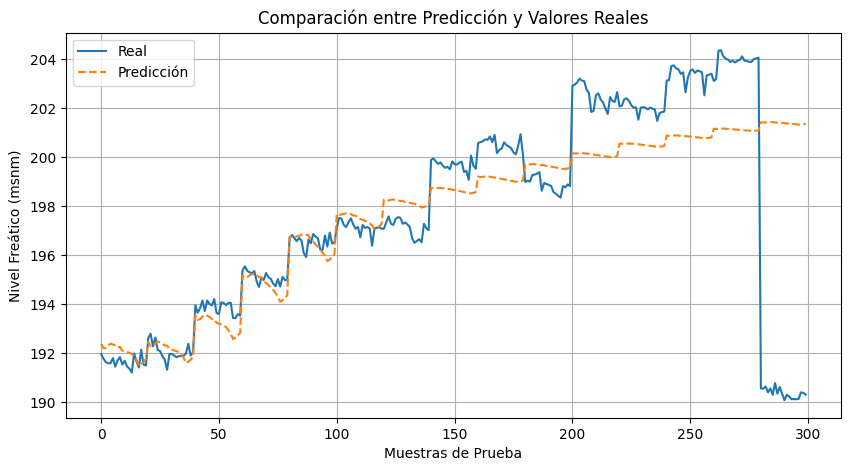

In [ ]:
import matplotlib.pyplot as plt

# Hacer predicciones en el conjunto de prueba
y_pred_scaled = model.predict(X_test)

# Desescalar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Crear gráfico
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label="Real", linestyle="-")
plt.plot(y_pred, label="Predicción", linestyle="dashed")
plt.xlabel("Muestras de Prueba")
plt.ylabel("Nivel Freático (msnm)")
plt.title("Comparación entre Predicción y Valores Reales")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_descaled, y_pred)
print(f"🔹 Coeficiente de Determinación R²: {r2:.2f}")


🔹 Coeficiente de Determinación R²: 0.45


In [ ]:
# Obtener el ID codificado de 60040
id_60040_codificado = label_encoder.transform([60040])[0]

print(f"🔹 ID del freatímetro 60040 codificado: {id_60040_codificado}")


🔹 ID del freatímetro 60040 codificado: 0


In [ ]:
# Desescalar las predicciones y los valores reales si aún no lo has hecho
y_pred_desescalado = scaler_y.inverse_transform(y_pred_scaled)
y_test_desescalado = scaler_y.inverse_transform(y_test)

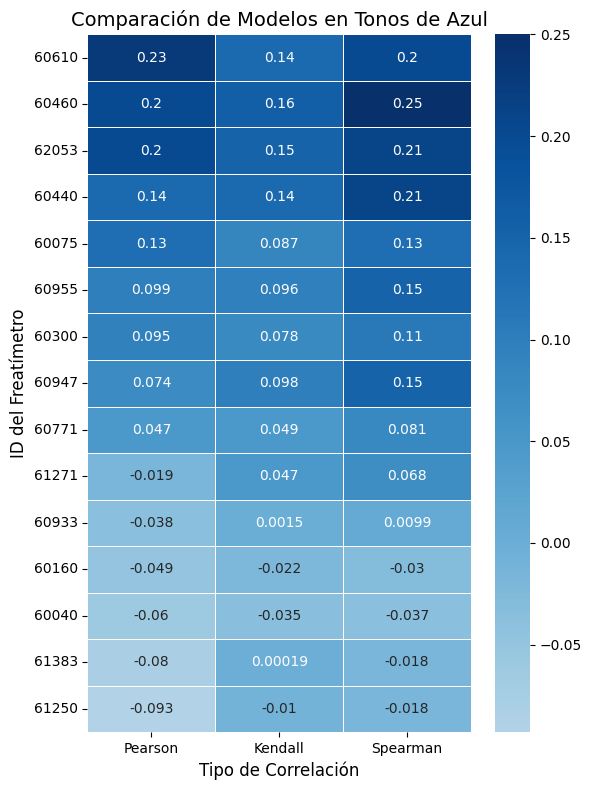

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1) Definir los freatímetros y sus correlaciones en listas (orden: de arriba hacia abajo)
freatimetros = [60610, 60460, 62053, 60440, 60075, 60955, 60300, 60947, 60771,
                61271, 60933, 60160, 60040, 61383, 61250]

pearson = [0.23, 0.20, 0.20, 0.14, 0.13, 0.099, 0.095, 0.074, 0.047,
          -0.019, -0.038, -0.049, -0.06, -0.08, -0.093]

kendall = [0.14, 0.16, 0.15, 0.14, 0.087, 0.096, 0.078, 0.098, 0.049,
           0.047, 0.0015, -0.022,-0.035, 0.00019, -0.01]

spearman = [0.2, 0.25, 0.21, 0.21, 0.13, 0.15, 0.11, 0.15, 0.081,
            0.068, 0.0099, -0.03, -0.037, -0.018, -0.018]

# 2) Construir un DataFrame con columnas para cada tipo de correlación
df_correl = pd.DataFrame({
    'Pearson': pearson,
    'Kendall': kendall,
    'Spearman': spearman
}, index=freatimetros)

# Opcional: ordenar el índice de mayor a menor correlación de Pearson,
# o dejarlo en tu orden preferido
# df_correl = df_correl.sort_values(by='Pearson', ascending=False)

# 3) Crear el mapa de calor (heatmap) con seaborn
plt.figure(figsize=(6, 8))  # Ajusta el tamaño según convenga
sns.heatmap(df_correl,
            cmap='Blues',   # Paleta de tonos azules
            center=0,       # Para que 0 sea el punto medio del degradado
            annot=True,     # Muestra los valores en cada celda
            fmt=".3g",      # Formato numérico (tres dígitos significativos)
            linewidths=0.5, # Separación entre celdas
            cbar=True       # Muestra la barra lateral de colores
           )

plt.title("Comparación de Modelos en Tonos de Azul", fontsize=14)
plt.xlabel("Tipo de Correlación", fontsize=12)
plt.ylabel("ID del Freatímetro", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
archivo_excel = '/content/drive/MyDrive/Datos Tesis/datasetRedNcaso2.xlsx'
nombre_pestaña = 'Sheet1'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datasetMerge = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)
print (datasetMerge.head())

   Unnamed: 0.1    nivelRio   Temp Out    Hi Temp   Low Temp    Out Hum  \
0             0  236.547742  15.532369  15.707670  15.357260  51.051134   
1             1  236.556429  13.979232  14.164694  13.796521  54.516615   
2             2  236.584839  16.249733  16.422186  16.075099  55.321884   
3             3  236.864667  12.937151  13.085438  12.785879  58.804169   
4             4  236.268333  12.763769  12.929717  12.597198  51.613506   

    Dew Pt.  Wind Speed  Wind Run   Hi Speed  ...   60610       60771  \
0  3.838688    2.445683  0.408693   7.036951  ...  198.18  199.617973   
1  3.505192    2.515057  0.420649   7.873105  ...  197.48  199.500000   
2  6.083175    4.073986  0.680005  11.190934  ...  197.18  199.850000   
3  3.916524    1.396049  0.233429   5.159052  ...  197.51  199.520000   
4  1.567696    4.217409  0.703767  10.239559  ...  197.33  199.760000   

        60933       60947       60955       61250       61271       61383  \
0  199.950000  198.883900  202.46

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]  # Asegúrate de que esta lista contenga todos los freatímetros que desees incluir.
# Agrega aquí otras variables de interés si lo deseas
variables_interes = [ 'Temp Out', 'Hi Temp', 'Low Temp', 'Out Hum', 'Dew Pt.',
       'Wind Speed', 'Wind Run', 'Hi Speed', 'Bar  ', 'Rain', 'Rain Rate', 'Solar Energy', 'Heat D-D ', 'Cool D-D ', 'In Temp', 'In  Hum',
       'In  Dew', 'In  Heat', 'In  ET'
       ,]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

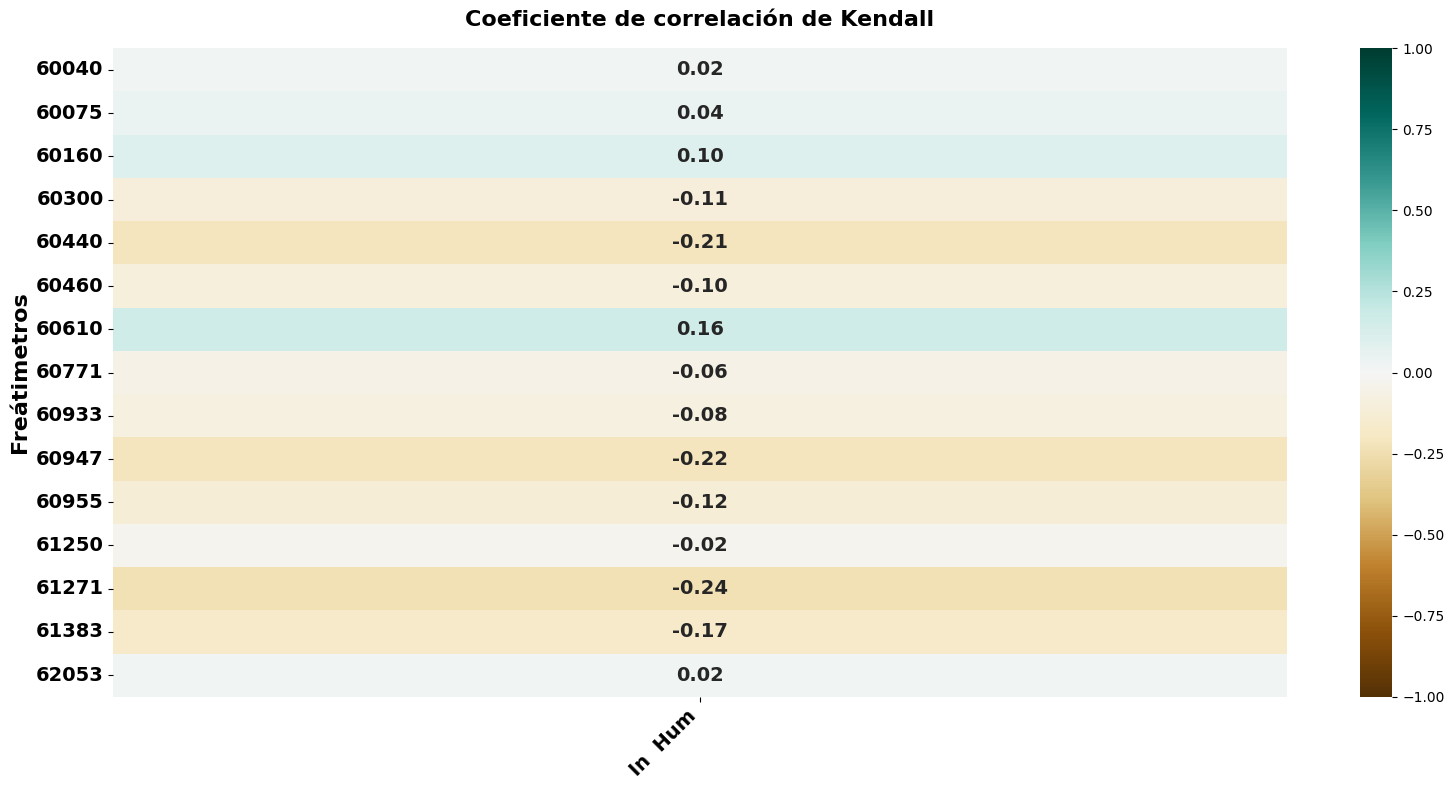

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
aux = datasetMerge[columnas_interes].corr(method='kendall')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.2).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 2].index  # Variables que cumplen la condición



# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Kendall',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
# Transformar el dataset al formato "long" para incluir todos los freátimetros
# Identificar las columnas de los freátimetros
freatimetro_columns = [60040, 60075, 60160, 60300, 60440, 60460, 60610,
                       60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]
#'In  Dew','Hi Speed'

# Usar pandas.melt para transformar el dataset
long_data = pd.melt(
    datasetMerge,
    id_vars=['fecha','In  Hum' ,'Wind Speed', 'Wind Run','Solar Energy'],  # Variables comunes
    value_vars=freatimetro_columns,  # Columnas de freátimetros
    var_name='freátimetro_id',       # Nombre de la columna de identificadores
    value_name='nivel_freatico'      # Valores de los niveles freáticos
)

# Ordenar por fecha para preservar la secuencia temporal
long_data.sort_values(by=['fecha', 'freátimetro_id'], inplace=True)
# Verificar el formato de la columna 'fecha'
print(long_data['fecha'].dtype)
print(long_data['fecha'].head())
long_data = long_data[
    (long_data['fecha'].dt.month.isin([1, 2, 3, 4,9,10,11,12])) &
    (long_data['fecha'].dt.year.between(2010, 2019))
]

# Revisar el resultado de la transformación
print(long_data.head())

datetime64[ns]
0     2010-01-01
80    2010-01-01
160   2010-01-01
240   2010-01-01
320   2010-01-01
Name: fecha, dtype: datetime64[ns]
         fecha    In  Hum  Wind Speed  Wind Run  Solar Energy freátimetro_id  \
0   2010-01-01  44.648818    2.445683  0.408693          2.97          60040   
80  2010-01-01  44.648818    2.445683  0.408693          2.97          60075   
160 2010-01-01  44.648818    2.445683  0.408693          2.97          60160   
240 2010-01-01  44.648818    2.445683  0.408693          2.97          60300   
320 2010-01-01  44.648818    2.445683  0.408693          2.97          60440   

     nivel_freatico  
0           191.432  
80          192.015  
160         194.180  
240         195.252  
320         197.180  


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])
long_data['año'] = long_data['fecha'].dt.year
long_data['mes'] = long_data['fecha'].dt.month
long_data['dia'] = long_data['fecha'].dt.day

# Seleccionar las características (X) y el objetivo (y)
features = ['año','mes', 'dia','In  Hum' ,'Wind Speed', 'Wind Run','Solar Energy','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.9039 - mae: 0.7885 - val_loss: 0.7769 - val_mae: 0.6884
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6717 - mae: 0.6097 - val_loss: 0.6305 - val_mae: 0.5971
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5327 - mae: 0.4709 - val_loss: 0.5508 - val_mae: 0.5216
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4333 - mae: 0.4171 - val_loss: 0.5163 - val_mae: 0.5026
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5406 - mae: 0.4574 - val_loss: 0.4821 - val_mae: 0.4742
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3448 - mae: 0.3520 - val_loss: 0.5082 - val_mae: 0.5121
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3892 - mae: 0.3923 - val_loss: 0.4279 - val_mae: 0.4431
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3325 - mae: 0.3346 - val_loss: 0.4134 - val_mae: 0.4417
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
Loss (MSE): 0.06762822717428207, MAE: 0.2252059429883957
Primeras predicciones vs valores reales con IDs originales:
Freátimetro ID: 60040, Predicción: 190.79, Real: 191.52
Freátimetro ID: 60075, Predicción: 191.35, Real: 191.75
Freátimetro ID: 60160, Predicción: 192.22, Real: 193.88
Freátimetro ID: 60300, Predicción: 193.36, Real: 195.41
Freátimetro ID: 60440, Predicción: 194.87, Real: 196.82


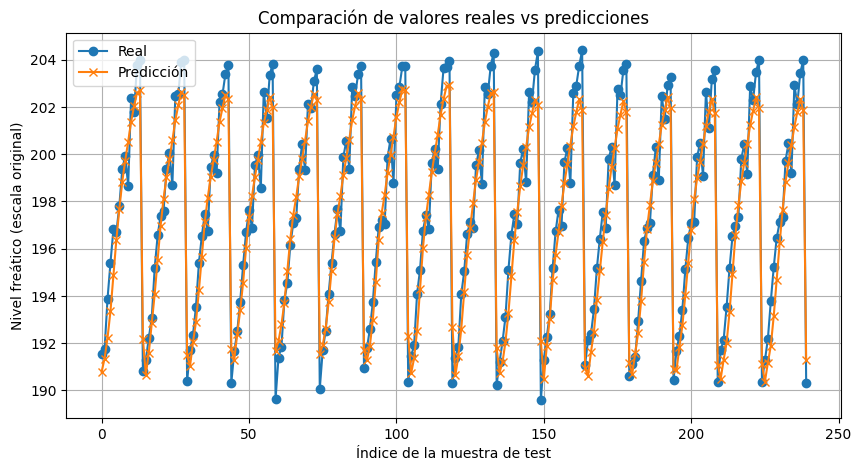

In [ ]:
import matplotlib.pyplot as plt

# EJEMPLO 1: Gráfico sencillo por índice de muestra
plt.figure(figsize=(10, 5))
plt.plot(y_test_descaled, label='Real', marker='o')
plt.plot(y_pred, label='Predicción', marker='x')
plt.title("Comparación de valores reales vs predicciones")
plt.xlabel("Índice de la muestra de test")
plt.ylabel("Nivel freático (escala original)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# Seleccionar las características (X) y el objetivo (y)
features = ['In  Hum' ,'Wind Speed', 'Wind Run','Solar Energy','freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=False))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")


NameError: name 'long_data' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])
long_data['año'] = long_data['fecha'].dt.year
long_data['mes'] = long_data['fecha'].dt.month
long_data['dia'] = long_data['fecha'].dt.day

# Seleccionar las características (X) y el objetivo (y)
features = ['año', 'mes', 'dia', 'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy', 'freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.5673 - mae: 0.6020 - val_loss: 0.3406 - val_mae: 0.5409
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1413 - mae: 0.2893 - val_loss: 0.2392 - val_mae: 0.4611
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0484 - mae: 0.1790 - val_loss: 0.2488 - val_mae: 0.4709
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0407 - mae: 0.1622 - val_loss: 0.1996 - val_mae: 0.4246
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0401 - mae: 0.1593 - val_loss: 0.2291 - val_mae: 0.4530
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0380 - mae: 0.1542 - val_loss: 0.2048 - val_mae: 0.4300
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0350 - mae: 0.1499 - val_loss: 0.2076 - val_mae: 0.4321
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0347 - mae: 0.1481 - val_loss: 0.2136 - val_mae: 0.4385
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Mantener una copia de los valores originales de 'freátimetro_id'
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# Convertir 'freátimetro_id' a una representación categórica para el modelo
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])
long_data['año'] = long_data['fecha'].dt.year
long_data['mes'] = long_data['fecha'].dt.month
long_data['dia'] = long_data['fecha'].dt.day

# Seleccionar las características (X) y el objetivo (y)
features = ['año', 'mes', 'dia', 'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy', 'freátimetro_id_encoded']
X = long_data[features].values
y = long_data['nivel_freatico'].values

# Escalar las variables numéricas
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X[:, :-1])  # Escalar las columnas numéricas, sin incluir 'freátimetro_id_encoded'

# Combinar las columnas escaladas con 'freátimetro_id_encoded' (no escalado)
X_combined = np.hstack((X_scaled, X[:, -1].reshape(-1, 1)))

# Escalar el objetivo
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, shuffle=False)

# Redimensionar X para que sea compatible con LSTM (secuencia de tiempo, características)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Crear un modelo LSTM para múltiples freátimetros
model = Sequential()
model.add(LSTM(256, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='relu', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# Evaluar el modelo
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Hacer predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_descaled = scaler_y.inverse_transform(y_test)

# Mostrar las métricas y las primeras predicciones, incluyendo el ID original
print(f"Loss (MSE): {loss}, MAE: {mae}")
print("Primeras predicciones vs valores reales con IDs originales:")
for pred, real, freatimetro_id in zip(y_pred[:5], y_test_descaled[:5], freatimetro_ids_original[:5]):
    print(f"Freátimetro ID: {freatimetro_id}, Predicción: {pred[0]:.2f}, Real: {real[0]:.2f}")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.9047 - mae: 0.7863 - val_loss: 0.7174 - val_mae: 0.6501
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5204 - mae: 0.4795 - val_loss: 0.5747 - val_mae: 0.5342
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5656 - mae: 0.4873 - val_loss: 0.5487 - val_mae: 0.5134
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5587 - mae: 0.4851 - val_loss: 0.5206 - val_mae: 0.4700
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5537 - mae: 0.4752 - val_loss: 0.5100 - val_mae: 0.4640
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4133 - mae: 0.4003 - val_loss: 0.5128 - val_mae: 0.4823
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5805 - mae: 0.4964 - val_loss: 0.4890 - val_mae: 0.4538
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4750 - mae: 0.4383 - val_loss: 0.4713 - val_mae: 0.4260
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4458 - mae: 0.4284 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Cargar y preparar datos (asumiendo que long_data es tu DataFrame)
# Mantener copia de IDs originales
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# 2. Ingeniería de características temporales
# Codificación cíclica para el mes
long_data['mes_sin'] = np.sin(2 * np.pi * long_data['mes'] / 12)
long_data['mes_cos'] = np.cos(2 * np.pi * long_data['mes'] / 12)

# Codificar IDs
label_encoder = LabelEncoder()
long_data['freátimetro_id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# 3. Selección de características
features = [
    'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy',
    'mes_sin', 'mes_cos', 'freátimetro_id_encoded'
]
X = long_data[features].values
y = long_data['nivel_freatico'].values

# 4. Creación de ventanas temporales
def create_sequences(data, target, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:i+window_size])
        y_seq.append(target[i+window_size])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 6  # Ajustar según análisis de autocorrelación
X_seq, y_seq = create_sequences(X, y, WINDOW_SIZE)

# 5. División de datos manteniendo orden temporal
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    shuffle=False
)

# 6. Escalado (evitando data leakage)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Escalar características usando solo datos de entrenamiento
X_train_shape = X_train.shape
X_train = scaler_X.fit_transform(X_train.reshape(-1, X_train_shape[-1])).reshape(X_train_shape)
X_test = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

# Escalar target
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# 7. Construcción del modelo LSTM mejorado
model = Sequential([
    LSTM(128,
         input_shape=(WINDOW_SIZE, X_train.shape[2]),
         return_sequences=True,
         dropout=0.2,
         recurrent_dropout=0.2),
    LSTM(64,
         dropout=0.2,
         recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 8. Entrenamiento con early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 9. Evaluación y predicciones
loss, mae = model.evaluate(X_test, y_test, verbose=1)

# Obtener predicciones
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_descaled = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# 10. Resultados (ajustar índices según ventana)
print(f"\nLoss (MSE): {loss:.4f}, MAE: {mae:.4f}")
print("Predicciones vs Valores reales (primeros 5 ejemplos):")
for i in range(5):
    print(f"ID: {freatimetro_ids_original[i + WINDOW_SIZE]} | Pred: {y_pred[i][0]:.2f} | Real: {y_test_descaled[i][0]:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.5493 - mae: 0.5799 - val_loss: 0.2965 - val_mae: 0.5198
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.2276 - mae: 0.3397 - val_loss: 0.4612 - val_mae: 0.6334
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1968 - mae: 0.3146 - val_loss: 0.3172 - val_mae: 0.5340
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1988 - mae: 0.3056 - val_loss: 0.3927 - val_mae: 0.5963
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1844 - mae: 0.2863 - val_loss: 0.4058 - val_mae: 0.6072
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1939 - mae: 0.2893 - val_loss: 0.3766 - val_mae: 0.5847
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1882 - mae: 0.2963 - val_loss: 0.3628 - val_mae: 0.5751
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1973 - mae: 0.3180 - val_loss: 0.3074 - val_mae: 0.5355
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - l

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# 1. Cargar y preparar datos
# =============================================================================
# Asumiendo que long_data es tu DataFrame con columnas:
# ['fecha', 'In Hum', 'Wind Speed', 'Wind Run', 'Solar Energy', 'freátimetro_id', 'nivel_freatico']

# Mantener copia de IDs originales
freatimetro_ids_original = long_data['freátimetro_id'].copy()

# 2. Ingeniería de características temporales
# =============================================================================
# Codificación cíclica para el mes
long_data['mes'] = long_data['fecha'].dt.month
long_data['mes_sin'] = np.sin(2 * np.pi * long_data['mes'] / 12)
long_data['mes_cos'] = np.cos(2 * np.pi * long_data['mes'] / 12)

# Codificar IDs de freátimetros
label_encoder = LabelEncoder()
long_data['id_encoded'] = label_encoder.fit_transform(long_data['freátimetro_id'])

# 3. Selección de características
# =============================================================================
features = [
    'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy',
    'mes_sin', 'mes_cos', 'id_encoded'
]
target = 'nivel_freatico'

# 4. Función para crear secuencias temporales por freátimetro
# =============================================================================
def create_sequences(data, window_size=4):
    X_seq, y_seq, ids_seq = [], [], []
    for freat_id in data['freátimetro_id'].unique():
        grupo = data[data['freátimetro_id'] == freat_id].sort_values('fecha')
        if len(grupo) < window_size + 1:
            continue  # Saltar freátimetros con pocos datos

        valores = grupo[features].values
        target_vals = grupo[target].values

        for i in range(len(valores) - window_size):
            X_seq.append(valores[i:i+window_size])
            y_seq.append(target_vals[i+window_size])
            ids_seq.append(freat_id)

    return np.array(X_seq), np.array(y_seq), np.array(ids_seq)

# 5. Creación de secuencias y división temporal
# =============================================================================
WINDOW_SIZE = 4  # Ventana de 4 meses
X_seq, y_seq, ids_seq = create_sequences(long_data, WINDOW_SIZE)

# Función para dividir series temporales manteniendo la cronología por freátimetro
def temporal_train_test_split(X, y, ids, test_size=0.2):
    X_train, X_test, y_train, y_test = [], [], [], []

    for freat_id in np.unique(ids):
        mask = (ids == freat_id)
        split_idx = int(np.sum(mask) * (1 - test_size))

        X_train.append(X[mask][:split_idx])
        X_test.append(X[mask][split_idx:])
        y_train.append(y[mask][:split_idx])
        y_test.append(y[mask][split_idx:])

    return (np.concatenate(X_train), np.concatenate(X_test),
            np.concatenate(y_train), np.concatenate(y_test))

# División de datos (80% entrenamiento, 20% prueba por cada freátimetro)
X_train, X_test, y_train, y_test = temporal_train_test_split(X_seq, y_seq, ids_seq)

# 6. Escalado seguro (sin data leakage)
# =============================================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Escalar características
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# Escalar target
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# 7. Construcción del modelo LSTM mejorado
# =============================================================================
model = Sequential([
    LSTM(128,
         input_shape=(WINDOW_SIZE, X_train_scaled.shape[2]),
         return_sequences=True,
         dropout=0.2,
         recurrent_dropout=0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 8. Entrenamiento con early stopping
# =============================================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 9. Evaluación y predicciones
# =============================================================================
# Evaluación en datos de prueba
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled, verbose=1)

# Predicciones
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# 10. Resultados y verificación
# =============================================================================
print(f"\nMSE en test: {test_loss:.4f}, MAE en test: {test_mae:.4f}")

# Verificación de freátimetros en ambos conjuntos
print("\nFreátimetros en entrenamiento:", np.unique(ids_seq[np.isin(ids_seq, np.unique(ids_train))]))
print("Freátimetros en prueba:", np.unique(ids_seq[np.isin(ids_seq, np.unique(ids_test))]))

# Ejemplo de predicciones
print("\nEjemplos de predicción vs real:")
for i in range(5):
    print(f"ID: {ids_test[i]} | Pred: {y_pred[i][0]:.2f} | Real: {y_true[i][0]:.2f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 0.5457 - mae: 0.6011 - val_loss: 2.7044 - val_mae: 1.1881
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2177 - mae: 0.3250 - val_loss: 2.8621 - val_mae: 1.1790
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2497 - mae: 0.3613 - val_loss: 3.6731 - val_mae: 1.1536
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1735 - mae: 0.2946 - val_loss: 3.2474 - val_mae: 1.1356
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2100 - mae: 0.3082 - val_loss: 3.4740 - val_mae: 1.1352
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1689 - mae: 0.2733 - val_loss: 3.4231 - val_mae: 1.1248
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.1828 - mae: 0.2842 - val_loss: 3.4615 - val_mae: 1.1280
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2170 - mae: 0.3066 - val_loss: 3.9178 - val_mae: 1.2251
Epoch 9/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - l

NameError: name 'ids_train' is not defined

In [ ]:
long_data['año'] = long_data['fecha'].dt.year

In [ ]:
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Supongamos que tu DataFrame se llama long_data y ya contiene solo los
# meses de riego (8 meses/año) desde 2010 a 2019.

# Asegúrate de que esté ordenado primero por freátimetro_id y luego por fecha:
long_data = long_data.sort_values(by=['freátimetro_id', 'fecha']).reset_index(drop=True)


In [ ]:
long_data['mes_sin'] = np.sin(2 * np.pi * ((long_data['mes']-1) / 8.0))
long_data['mes_cos'] = np.cos(2 * np.pi * ((long_data['mes']-1) / 8.0))


In [ ]:
features = [ 'año','mes_sin','mes_cos', 'In  Hum', 'Wind Speed', 'Wind Run', 'Solar Energy']
target = 'nivel_freatico'


In [ ]:
# Extraer la matriz X (features) y y (target), además de los IDs y fechas
X_all = long_data[features].values  # Todas las filas, columnas definidas
y_all = long_data[target].values
freat_ids_all = long_data['freátimetro_id'].values  # para restaurar luego
fechas_all = long_data['fecha'].values

# Escaladores
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Ajustamos los escaladores con TODOS los datos (global)
X_all_scaled = scaler_X.fit_transform(X_all)
y_all_scaled = scaler_y.fit_transform(y_all.reshape(-1, 1)).flatten()
# .flatten() para mantener vector 1D


In [ ]:
def create_sequences_by_id(X, y, ids, fechas, n_steps=3):
    """
    Crea ventanas de largo n_steps para cada freátimetro sin mezclarlos.

    Parámetros:
    -----------
    X: np.ndarray de forma (N, num_features) -- escalado
    y: np.ndarray de forma (N,) -- escalado
    ids: np.ndarray de forma (N,) con el ID del freátimetro
    fechas: np.ndarray de forma (N,) con la fecha
    n_steps: int, tamaño de la ventana temporal

    Retorna:
    --------
    X_seq: np.ndarray de forma (total_muestras, n_steps, num_features)
    y_seq: np.ndarray de forma (total_muestras,)
    ids_seq: np.ndarray de forma (total_muestras,) con el ID correspondiente
    fechas_seq: np.ndarray de forma (total_muestras,) con la última fecha de la ventana (opcional)
    """
    X_seq, y_seq = [], []
    ids_seq = []
    fechas_seq = []

    # Indices únicos de freátimetros en orden
    unique_ids = np.unique(ids)

    for f_id in unique_ids:
        # Extraer las filas correspondientes a este freátimetro
        mask = (ids == f_id)
        X_f = X[mask]
        y_f = y[mask]
        fechas_f = fechas[mask]

        # Crear ventanas para este freátimetro
        for i in range(len(X_f) - n_steps):
            X_seq.append(X_f[i:i+n_steps])
            y_seq.append(y_f[i + n_steps])
            ids_seq.append(f_id)
            # Guardar la fecha "target" como la del paso final
            fechas_seq.append(fechas_f[i + n_steps])

    return (np.array(X_seq),
            np.array(y_seq),
            np.array(ids_seq),
            np.array(fechas_seq))

# Creamos secuencias con n_steps=3 (ejemplo)
n_steps = 10
X_seq, y_seq, ids_seq, fechas_seq = create_sequences_by_id(
    X_all_scaled, y_all_scaled, freat_ids_all, fechas_all, n_steps=n_steps
)

print("Forma de X_seq:", X_seq.shape)   # (muestras_totales, 3, num_features)
print("Forma de y_seq:", y_seq.shape)   # (muestras_totales,)
print("Forma de ids_seq:", ids_seq.shape)
print("Forma de fechas_seq:", fechas_seq.shape)


Forma de X_seq: (1050, 10, 7)
Forma de y_seq: (1050,)
Forma de ids_seq: (1050,)
Forma de fechas_seq: (1050,)


In [ ]:
# OJO: X_seq ya está "concatenado" de todos los IDs en orden de ID y fecha
# Si quieres un split puramente temporal, deberías separar por fecha.
# Aquí, por simplicidad, haremos un 80/20 sin shuffle:

train_size = int(0.8 * len(X_seq))

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]
ids_train = ids_seq[:train_size]
fechas_train = fechas_seq[:train_size]

X_test = X_seq[train_size:]
y_test = y_seq[train_size:]
ids_test = ids_seq[train_size:]
fechas_test = fechas_seq[train_size:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)


Train shapes: (840, 10, 7) (840,)
Test shapes : (210, 10, 7) (210,)


In [ ]:
# Definir la arquitectura del modelo
num_features = X_train.shape[2]

model = Sequential()
model.add(
    LSTM(
        units=128,
        input_shape=(n_steps, num_features),
        activation='relu',
        return_sequences=False
    )
)
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

# Entrenamos
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,  # 20% de train como validación interna
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 128)                 │          69,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,953 (304.50 KB)

 Trainable params: 77,953 (304.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.5080 - mae: 0.5933 - val_loss: 2.0059 - val_mae: 1.3831
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4785 - mae: 0.5863 - val_loss: 2.1239 - val_mae: 1.4207
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4610 - mae: 0.5761 - val_loss: 2.0731 - val_mae: 1.4024
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4774 - mae: 0.5959 - val_loss: 1.9017 - val_mae: 1.3437
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4866 - mae: 0.5861 - val_loss: 2.0966 - val_mae: 1.4152
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4835 - mae: 0.5978 - val_loss: 1.9535 - val_mae: 1.3601
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4937 - mae: 0.6011 - val_loss: 1.8183 - val_mae: 1.3089
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4845 - mae: 0.5958 - val_loss: 1.9734 - val_mae: 1.3671
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

In [ ]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (MSE escalado): {loss:.4f}, Test MAE escalado: {mae:.4f}")

# Predicciones
y_pred_scaled = model.predict(X_test)
# Desescalar
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6105 - mae: 1.6081 
Test Loss (MSE escalado): 2.5180, Test MAE escalado: 1.5749
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [ ]:
results_df = pd.DataFrame({
    'freátimetro_id': ids_test,
    'fecha': fechas_test,
    'prediccion': y_pred,
    'real': y_test_inv
})

# Ordenar por ID y fecha, si deseas
results_df = results_df.sort_values(by=['freátimetro_id', 'fecha']).reset_index(drop=True)

print(results_df.head(300))


     freátimetro_id      fecha  prediccion        real
0             61271 2011-01-01  196.152588  203.257000
1             61271 2011-02-01  196.271362  202.957000
2             61271 2011-03-01  196.308472  202.707000
3             61271 2011-04-01  196.271118  202.809878
4             61271 2011-09-01  196.177933  202.507000
..              ...        ...         ...         ...
211           62053 2019-04-01  195.907715  190.595000
212           62053 2019-09-01  195.677353  190.445000
213           62053 2019-10-01  195.910965  190.369593
214           62053 2019-11-01  195.902695  190.365000
215           62053 2019-12-01  195.841492  190.325000

[216 rows x 4 columns]


In [ ]:
print(f"\nTest Loss (MSE): {loss}, MAE: {mae}")
print("Primeras 5 predicciones vs valores reales con IDs y fechas:")
for i in range(5):
    print(f"Freátimetro ID: {results_df.loc[i,'freátimetro_id']}, "
          f"Fecha: {results_df.loc[i,'fecha']}, "
          f"Pred: {results_df.loc[i,'prediccion']:.2f}, "
          f"Real: {results_df.loc[i,'real']:.2f}")



Test Loss (MSE): 2.5383877754211426, MAE: 1.5798249244689941
Primeras 5 predicciones vs valores reales con IDs y fechas:
Freátimetro ID: 61271, Fecha: 2011-01-01 00:00:00, Pred: 196.15, Real: 203.26
Freátimetro ID: 61271, Fecha: 2011-02-01 00:00:00, Pred: 196.27, Real: 202.96
Freátimetro ID: 61271, Fecha: 2011-03-01 00:00:00, Pred: 196.31, Real: 202.71
Freátimetro ID: 61271, Fecha: 2011-04-01 00:00:00, Pred: 196.27, Real: 202.81
Freátimetro ID: 61271, Fecha: 2011-09-01 00:00:00, Pred: 196.18, Real: 202.51


In [ ]:
import numpy as np
import pandas as pd

# Scikit-learn para escalado y división de datos
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# TensorFlow / Keras para la red densa
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# =======================
# 1) PREPARACIÓN DE DATOS
# =======================

# Asegurarnos de que long_data esté ordenado cronológicamente
long_data = long_data.sort_values(by='fecha').reset_index(drop=True)

# Crear columnas cíclicas para 'mes' y 'dia'
# (Si 'mes' va de 1..12, y 'dia' de 1..31. Ajustar según tus datos.)
long_data['mes_sin'] = np.sin(2 * np.pi * long_data['mes'] / 12.0)
long_data['mes_cos'] = np.cos(2 * np.pi * long_data['mes'] / 12.0)

# Definir las columnas de entrada (features) y la columna objetivo (target)
features = [
    'año',
    'mes_sin', 'mes_cos',
    'In  Hum',
    'Wind Speed',
    'Wind Run',
    'Solar Energy'
]

target = 'nivel_freatico'

# Extraer las matrices/arrays
X_all = long_data[features].values
y_all = long_data[target].values.reshape(-1, 1)  # Como columna 2D

# (Opcional) Guardar columnas extra para analizar resultados después
fechas_all = long_data['fecha'].values
ids_all = long_data['freátimetro_id'].values

# Escalado de características y objetivo
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_all_scaled = scaler_X.fit_transform(X_all)
y_all_scaled = scaler_y.fit_transform(y_all)

# ===========================================
# 2) SEPARACIÓN ENTRE ENTRENAMIENTO Y PRUEBA
# ===========================================
# Usamos un 80/20 sin mezclar (shuffle=False) para respetar orden temporal
X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled,
    y_all_scaled,
    test_size=0.2,
    shuffle=False
)

# También separamos fechas e IDs para interpretabilidad
fechas_train, fechas_test = train_test_split(
    fechas_all, test_size=0.2, shuffle=False
)
ids_train, ids_test = train_test_split(
    ids_all, test_size=0.2, shuffle=False
)

print("Tamaño de entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño de prueba:", X_test.shape, y_test.shape)

# ================================
# 3) CONSTRUCCIÓN DE LA RED DENSA
# ================================

num_features = X_train.shape[1]  # Número de columnas de entrada

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=num_features))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))  # Salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

# ======================
# 4) ENTRENAMIENTO (FIT)
# ======================

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,  # 20% del set de entrenamiento para validación interna
    verbose=1
)

# =========================
# 5) EVALUACIÓN Y PREDICCIÓN
# =========================

loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest MSE (escalado): {loss:.4f}, Test MAE (escalado): {mae:.4f}")

# Generamos predicciones en el set de prueba
y_pred_scaled = model.predict(X_test)

# Invertir la escala de las predicciones y la del target
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# ========================
# 6) ANÁLISIS DE RESULTADOS
# ========================

# Construir un DataFrame para comparar
results_df = pd.DataFrame({
    'fecha': fechas_test,
    'freátimetro_id': ids_test,
    'prediccion': y_pred.flatten(),
    'real': y_test_real.flatten()
})

# Ordenar para análisis (opcional)
results_df = results_df.sort_values(by=['freátimetro_id', 'fecha']).reset_index(drop=True)

# Mostrar algunas filas
print("\nPrimeras filas de resultados:")
print(results_df.head(10))

# Ejemplo simple de comparación en el test set
for i in range(5):
    print(f"ID: {results_df.loc[i,'freátimetro_id']}, "
          f"Fecha: {results_df.loc[i,'fecha']}, "
          f"Pred: {results_df.loc[i,'prediccion']:.2f}, "
          f"Real: {results_df.loc[i,'real']:.2f}")


Tamaño de entrenamiento: (960, 7) (960, 1)
Tamaño de prueba: (240, 7) (240, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9912 - mae: 0.8462 - val_loss: 1.0463 - val_mae: 0.8675
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9501 - mae: 0.8216 - val_loss: 1.0136 - val_mae: 0.8577
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9911 - mae: 0.8532 - val_loss: 1.0212 - val_mae: 0.8608
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0006 - mae: 0.8508 - val_loss: 1.0308 - val_mae: 0.8636
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9957 - mae: 0.8496 - val_loss: 1.0092 - val_mae: 0.8564
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0143 - mae: 0.8677 - val_loss: 1.0272 - val_mae: 0.8627
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9434 - mae: 0.8198 - val_loss: 1.0184 - val_mae: 0.8601
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0005 - mae: 0.8602 - val_loss: 1.0169 - val_mae: 0.8598
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.000

In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import os

# Cargar el archivo CSV en un DataFrame
file_path = "/content/drive/MyDrive/Datos Tesis/datosCanalRiego.csv"
df = pd.read_csv(file_path)

# Convertir columnas numéricas a formato decimal con 2 decimales sin notación científica
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols] = df[numeric_cols].round(2)

# Guardar el DataFrame en un archivo Excel asegurando la correcta conversión de datos numéricos
excel_file_path = "/content/drive/MyDrive/Datos Tesis/datosCanalRiego.xlsx"

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    df.to_excel(writer, index=False, sheet_name="Muestras")

# Verificar si el archivo se ha guardado correctamente
file_exists = os.path.exists(excel_file_path)

# Devolver la ruta del archivo para su descarga
if file_exists:
    print(f"Archivo Excel guardado en: {excel_file_path}")
else:
    print("Error al guardar el archivo Excel.")

Archivo Excel guardado en: /content/drive/MyDrive/Datos Tesis/datosCanalRiego.xlsx


In [ ]:
import pandas as pd
import numpy as np
archivo_excel = '/content/drive/MyDrive/Datos Tesis/datosCanalRiego.xlsx'
nombre_pestaña = 'Muestras'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
caudal_canalRiego = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)
caudal_canalRiego['Caudal'] = caudal_canalRiego['Caudal'].replace(0, np.nan)
print (caudal_canalRiego.head())

    Mes  Mañana  Tarde   Caudal   Año  Día Abertura
0  SEPT    1.50   1.69  6346.67  2009  1.0     0.39
1  SEPT    1.65   1.80  6701.50  2009  2.0     0.39
2  SEPT    1.65   1.70  6701.50  2009  3.0     0.39
3  SEPT    1.78   1.68  7993.81  2009  4.0     0.45
4  SEPT    1.75   1.66  7916.32  2009  5.0     0.45


In [ ]:
nulos_columna = caudal_canalRiego['Caudal'].isnull().sum() +  (caudal_canalRiego['Caudal'] == 0).sum()

print(f" tiene {nulos_columna} valores nulos o 0.")

 tiene 333 valores nulos o 0.


In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# Cargar el dataset
caudal_canalRiego.columns = caudal_canalRiego.columns.str.strip()

# Seleccionar solo las columnas relevantes (Caudal y otras numéricas)
columnas_numericas = caudal_canalRiego.select_dtypes(include=['number']).columns
df_numerico = caudal_canalRiego[columnas_numericas]

# Aplicar KNNImputer
imputer = KNNImputer(n_neighbors=5)  # Puedes ajustar el número de vecinos
df_imputado = pd.DataFrame(imputer.fit_transform(df_numerico), columns=df_numerico.columns)

# Reemplazar la columna Caudal en el dataset original
caudal_canalRiego['Caudal'] = df_imputado['Caudal']

# Guardar el dataset imputado (opcional)
caudal_canalRiego.to_csv('caudal_canalRiego_imputado.csv', index=False)

print(caudal_canalRiego)


        Mes  Mañana  Tarde     Caudal   Año   Día Abertura
0      SEPT    1.50   1.69   6346.670  2009   1.0     0.39
1      SEPT    1.65   1.80   6701.500  2009   2.0     0.39
2      SEPT    1.65   1.70   6701.500  2009   3.0     0.39
3      SEPT    1.78   1.68   7993.810  2009   4.0     0.45
4      SEPT    1.75   1.66   7916.320  2009   5.0     0.45
...     ...     ...    ...        ...   ...   ...      ...
2910  ABRIL     NaN    NaN  14899.484  2021  26.0      NaN
2911  ABRIL     NaN    NaN  15132.806  2021  27.0      NaN
2912  ABRIL     NaN    NaN  15121.382  2021  28.0      NaN
2913  ABRIL     NaN    NaN  15281.402  2021  29.0      NaN
2914  ABRIL     NaN    NaN  15564.678  2021  30.0      NaN

[2915 rows x 7 columns]


In [ ]:
nulos_columna = caudal_canalRiego['Caudal'].isnull().sum() +  (caudal_canalRiego['Caudal'] == 0).sum()

print(f" tiene {nulos_columna} valores nulos o 0.")

 tiene 0 valores nulos o 0.


In [ ]:
import pandas as pd

# Diccionario para convertir nombres de meses a números
meses_dict = {
    'ENERO': 1, 'FEB': 2, 'MAR': 3, 'ABRIL': 4,'SEPT': 9, 'OCT.': 10, 'NOV.': 11, 'DIC.': 12}

# Cargar el archivo
df = caudal_canalRiego

# Convertir la columna "Mes" a string, eliminar espacios y poner en mayúsculas
df['Mes'] = df['Mes'].astype(str).str.strip().str.upper()

# Reemplazar nombres de meses por números si existen en el diccionario
df['Mes'] = df['Mes'].replace(meses_dict)

# Convertir "Mes" y "Año" a numérico (evitando errores con `errors='coerce'`)
df['Mes'] = pd.to_numeric(df['Mes'], errors='coerce')
df['Año'] = pd.to_numeric(df['Año'], errors='coerce')

# Revisar si hay valores NaN en Mes o Año
print("Valores nulos en Mes:", df['Mes'].isnull().sum())
print("Valores nulos en Año:", df['Año'].isnull().sum())

# Eliminar filas con Mes o Año nulos (si es necesario)
df = df.dropna(subset=['Mes', 'Año'])

# Convertir a enteros después de eliminar los NaN
df['Mes'] = df['Mes'].astype(int)
df['Año'] = df['Año'].astype(int)

# Crear la columna de Fecha con el día 01
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes'].astype(str) + '-01')

# Calcular el promedio mensual de 'Caudal'
df_promedio_mensual_canal = df.groupby(['Año', 'Mes'], as_index=False)['Caudal'].mean()

# Agregar la columna de Fecha en el dataset resultante
df_promedio_mensual_canal['Fecha'] = pd.to_datetime(df_promedio_mensual_canal['Año'].astype(str) + '-' + df_promedio_mensual_canal['Mes'].astype(str) + '-01')

# Mostrar los resultados
print(df_promedio_mensual_canal)


Valores nulos en Mes: 0
Valores nulos en Año: 0
     Año  Mes        Caudal      Fecha
0   2009    9  11133.281935 2009-09-01
1   2009   10  14859.735806 2009-10-01
2   2009   11  14813.817742 2009-11-01
3   2009   12  14958.162581 2009-12-01
4   2010    1  15239.536129 2010-01-01
..   ...  ...           ...        ...
91  2020   12  15672.787161 2020-12-01
92  2021    1  15403.733613 2021-01-01
93  2021    2  15539.249379 2021-02-01
94  2021    3  14463.557419 2021-03-01
95  2021    4  14461.827000 2021-04-01

[96 rows x 4 columns]


<ipython-input-12-405cd54eb1d3>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Mes'] = df['Mes'].replace(meses_dict)


In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
import os
excel_file_path = "/content/drive/MyDrive/Datos Tesis/df_promedio_mensual_canal.xlsx"

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    df_promedio_mensual_canal.to_excel(writer, index=False, sheet_name="Muestras")

# Verificar si el archivo se ha guardado correctamente
file_exists = os.path.exists(excel_file_path)

# Devolver la ruta del archivo para su descarga
if file_exists:
    print(f"Archivo Excel guardado en: {excel_file_path}")
else:
    print("Error al guardar el archivo Excel.")

Archivo Excel guardado en: /content/drive/MyDrive/Datos Tesis/df_promedio_mensual_canal.xlsx


In [ ]:
print(freatimetros_caso2)

     Unnamed: 0      index       60040       60075       60160       60300  \
0             0 2010-01-01  191.432000  192.015000  194.180000  195.252000   
1             1 2010-02-01  191.522000  191.985000  194.070000  195.132000   
2             2 2010-03-01  191.712000  192.555000  193.889057  195.252000   
3             3 2010-04-01  191.592000  192.535000  193.450000  195.752000   
8             8 2010-09-01  191.562000  191.815000  193.499619  194.282000   
..          ...        ...         ...         ...         ...         ...   
147         147 2022-04-01  191.662000  191.895000  194.060000  195.022000   
152         152 2022-09-01  191.418424  191.994037  193.434760  194.718171   
153         153 2022-10-01  192.142000  192.385000  193.430000  195.112000   
154         154 2022-11-01  191.539271  191.909331  193.591582  194.982785   
155         155 2022-12-01  191.495829  192.037601  193.537241  194.983411   

          60440       60460       60610       60771       60933

In [ ]:
import pandas as pd
import numpy as np
archivo_excel = '/content/drive/MyDrive/Datos Tesis/df_promedio_mensual_canal.xlsx'
nombre_pestaña = 'Muestras'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
df_promedio_mensual_canal = pd.read_excel(archivo_excel, sheet_name=nombre_pestaña)

In [ ]:

# Asegurar que la columna de fecha esté en formato datetime
df_promedio_mensual_canal["Fecha"] = pd.to_datetime(df_promedio_mensual_canal["Fecha"])
freatimetros_caso2["index"] = pd.to_datetime(freatimetros_caso2["index"])

# Realizar la unión tipo INNER JOIN con columnas diferentes
merged_df2 = pd.merge(df_promedio_mensual_canal, freatimetros_caso2,
                     left_on="Fecha", right_on="index", how="inner")

# Opcional: eliminar la columna duplicada si no se necesita
merged_df2.drop(columns=["index"], inplace=True)

# Mostrar las primeras filas del DataFrame resultante
print(merged_df2.head())

    Año  Mes        Caudal      Fecha  Unnamed: 0    60040    60075  \
0  2010    1  15239.536129 2010-01-01           0  191.432  192.015   
1  2010    2  13998.267586 2010-02-01           1  191.522  191.985   
2  2010    3  11949.071613 2010-03-01           2  191.712  192.555   
3  2010    4  14568.952667 2010-04-01           3  191.592  192.535   
4  2010    9  12048.284387 2010-09-01           8  191.562  191.815   

        60160    60300   60440  ...   60610       60771       60933  \
0  194.180000  195.252  197.18  ...  198.18  199.617973  199.950000   
1  194.070000  195.132  196.62  ...  197.48  199.500000  200.330000   
2  193.889057  195.252  196.58  ...  197.18  199.850000  199.990000   
3  193.450000  195.752  196.83  ...  197.51  199.520000  200.419136   
4  193.499619  194.282  196.34  ...  197.33  199.760000  200.550000   

        60947       60955       61250       61271       61383    62053  \
0  198.883900  202.467000  202.973000  202.957000  203.535000  190.675  

<ipython-input-15-f646eaff79a6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freatimetros_caso2["index"] = pd.to_datetime(freatimetros_caso2["index"])


In [ ]:
import os
excel_file_path = "/content/drive/MyDrive/Datos Tesis/merged_df2.xlsx"

with pd.ExcelWriter(excel_file_path, engine='xlsxwriter') as writer:
    merged_df2.to_excel(writer, index=False, sheet_name="Muestras")

# Verificar si el archivo se ha guardado correctamente
file_exists = os.path.exists(excel_file_path)

# Devolver la ruta del archivo para su descarga
if file_exists:
    print(f"Archivo Excel guardado en: {excel_file_path}")
else:
    print("Error al guardar el archivo Excel.")

Archivo Excel guardado en: /content/drive/MyDrive/Datos Tesis/merged_df2.xlsx


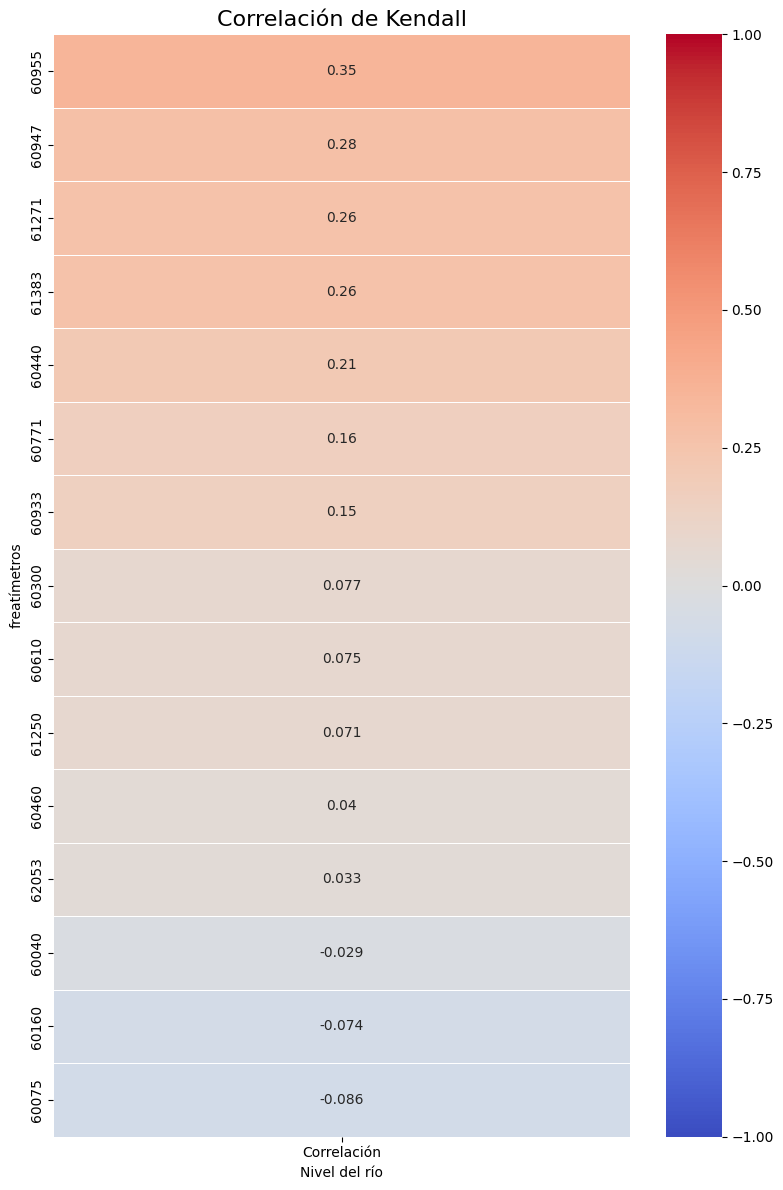

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau

# Lista de los 15 freatímetros
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

# Crear un DataFrame vacío para almacenar los coeficientes de correlación de Pearson
correlation_matrix = pd.DataFrame(index=freatimetros, columns=['Correlación'])

# Variable X: nivel promedio del río
nivel_rio = merged_df2['Caudal']

# Calcular la correlación de Pearson entre el nivel del río y cada freatímetro
for freatimetro in freatimetros:
    # Preparar los datos para calcular la correlación de Pearson
    data = {
        'Variable_X': nivel_rio,  # Nivel promedio del río
        'Variable_Y': merged_df2[freatimetro]  # Datos del freatímetro correspondiente
    }
    df = pd.DataFrame(data).dropna()  # Asegurarse de eliminar filas con NaNs

    # Calcular la correlación de Pearson
    if len(df) > 0:  # Verificar que haya datos suficientes
        correlation, _ = kendalltau(df['Variable_X'], df['Variable_Y'])
    else:
        correlation = np.nan

    # Rellenar la matriz con el valor de la correlación
    correlation_matrix.at[freatimetro, 'Correlación'] = correlation

# Convertir la matriz de correlación a tipo float
correlation_matrix = correlation_matrix.astype(float)

# Ordenar el DataFrame en orden descendente por el valor de la correlación
correlation_matrix = correlation_matrix.sort_values(by='Correlación', ascending=False)

# Crear el heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, linewidths=0.5)

# Configurar el título y las etiquetas del gráfico
plt.title('Correlación de Kendall', fontsize=16)
plt.xlabel('Nivel del río')
plt.ylabel('freatímetros')

# Mostrar el heatmap
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Crear los datos de correlación
data = {
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094],
    "Spearman": [0.60, 0.45, 0.38, 0.37, 0.31, 0.27, 0.24, 0.27, 0.17, 0.14, 0.14, 0.024, 0.0038, -0.061, -0.08],
    "Kendall": [0.43, 0.32, 0.28, 0.26, 0.21, 0.2, 0.19, 0.16, 0.12, 0.087, 0.089, 0.027, 0.011, -0.051, -0.022]
}

# Crear el DataFrame
df_correlaciones = pd.DataFrame(data)

# Mostrar la tabla
print(df_correlaciones)


   Freatímetro  Pearson  Spearman  Kendall
0        62053   0.6100    0.6000    0.430
1        60610   0.4100    0.4500    0.320
2        60460   0.3700    0.3800    0.280
3        61250   0.3300    0.3700    0.260
4        60160   0.3200    0.3100    0.210
5        60955   0.2700    0.2700    0.200
6        60075   0.2300    0.2400    0.190
7        60933   0.2000    0.2700    0.160
8        60771   0.1900    0.1700    0.120
9        60947   0.1500    0.1400    0.087
10       60440   0.1400    0.1400    0.089
11       61271   0.0480    0.0240    0.027
12       60300  -0.0068    0.0038    0.011
13       61383  -0.0300   -0.0610   -0.051
14       60040  -0.0940   -0.0800   -0.022


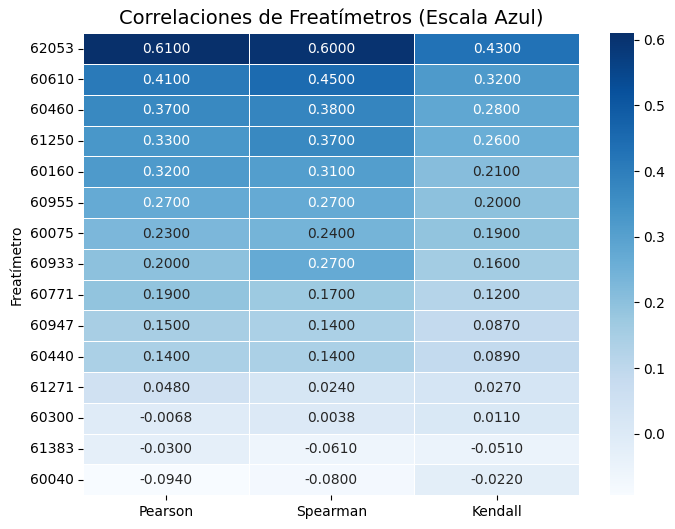

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear los datos de correlación
data = {
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094],
    "Spearman": [0.60, 0.45, 0.38, 0.37, 0.31, 0.27, 0.24, 0.27, 0.17, 0.14, 0.14, 0.024, 0.0038, -0.061, -0.08],
    "Kendall": [0.43, 0.32, 0.28, 0.26, 0.21, 0.2, 0.19, 0.16, 0.12, 0.087, 0.089, 0.027, 0.011, -0.051, -0.022]
}

# Crear el DataFrame
df_correlaciones = pd.DataFrame(data).set_index("Freatímetro")

# Crear la figura
fig, ax = plt.subplots(figsize=(8, 6))

# Generar el heatmap con escala de colores en azul
sns.heatmap(df_correlaciones, cmap="Blues", annot=True, fmt=".4f", linewidths=0.5, ax=ax)

# Configurar el título
ax.set_title("Correlaciones de Freatímetros (Escala Azul)", fontsize=14)

# Mostrar la tabla visualmente
plt.show()


In [ ]:
import pandas as pd

# Crear la tabla de distancia basada en la imagen
data_distancia = {
    "Freatímetro": [
        "62053", "60075", "60610", "61250", "61383", "60460",
        "60933", "60947", "60040", "60440", "60300", "60771",
        "60955", "60160", "61271"
    ],
    "Distancia": [250, 350, 400, 600, 600, 700, 900, 1200, 1350, 1550, 1600, 1900, 1900, 2000, 2000]
}

# Crear el DataFrame de distancia
df_distancia = pd.DataFrame(data_distancia)

# Crear los datos de correlación de Pearson
data_pearson = {
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094]
}

# Crear el DataFrame de correlación
df_pearson = pd.DataFrame(data_pearson)

# Unir la tabla de correlaciones con la tabla de distancia usando la columna "Freatímetro"
df_merged = pd.merge(df_pearson, df_distancia, on="Freatímetro", how="inner")

# Ordenar por distancia de menor a mayor
df_merged = df_merged.sort_values(by="Distancia", ascending=True).reset_index(drop=True)

# Categorizar la correlación en colores
def categorizar_correlacion(valor):
    if valor >= 0.5:
        return "Verde"  # Fuerte
    elif 0.2 <= valor < 0.5:
        return "Amarillo"  # Moderada
    else:
        return "Rojo"  # Débil

df_merged["Categoría"] = df_merged["Pearson"].apply(categorizar_correlacion)

# Mostrar la tabla resultante
print(df_merged)


   Freatímetro  Pearson  Distancia Categoría
0        62053   0.6100        250     Verde
1        60075   0.2300        350  Amarillo
2        60610   0.4100        400  Amarillo
3        61250   0.3300        600  Amarillo
4        61383  -0.0300        600      Rojo
5        60460   0.3700        700  Amarillo
6        60933   0.2000        900  Amarillo
7        60947   0.1500       1200      Rojo
8        60040  -0.0940       1350      Rojo
9        60440   0.1400       1550      Rojo
10       60300  -0.0068       1600      Rojo
11       60955   0.2700       1900  Amarillo
12       60771   0.1900       1900      Rojo
13       60160   0.3200       2000  Amarillo
14       61271   0.0480       2000      Rojo


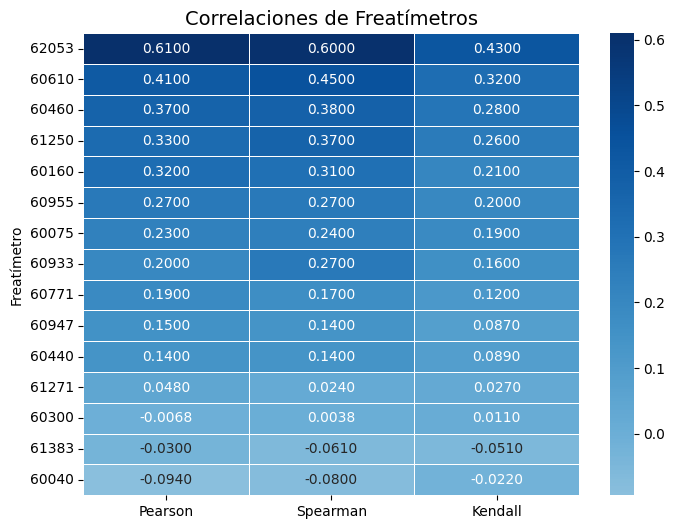

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el DataFrame con los datos proporcionados
df_correlaciones = pd.DataFrame({
    "Freatímetro": [
        "62053", "60610", "60460", "61250", "60160", "60955",
        "60075", "60933", "60771", "60947", "60440",
        "61271", "60300", "61383", "60040"
    ],
    "Pearson": [0.61, 0.41, 0.37, 0.33, 0.32, 0.27, 0.23, 0.2, 0.19, 0.15, 0.14, 0.048, -0.0068, -0.03, -0.094],
    "Spearman": [0.60, 0.45, 0.38, 0.37, 0.31, 0.27, 0.24, 0.27, 0.17, 0.14, 0.14, 0.024, 0.0038, -0.061, -0.08],
    "Kendall": [0.43, 0.32, 0.28, 0.26, 0.21, 0.2, 0.19, 0.16, 0.12, 0.087, 0.089, 0.027, 0.011, -0.051, -0.022]
})

# Crear una visualización en tabla con formato de colores
fig, ax = plt.subplots(figsize=(8, 6))

# Crear el heatmap con escala de azul para valores cercanos a 1 y -1, sin color para valores cercanos a 0
sns.heatmap(df_correlaciones.set_index("Freatímetro"), cmap="Blues", annot=True, fmt=".4f", linewidths=0.5, ax=ax, center=0)

# Configurar el título
ax.set_title("Correlaciones de Freatímetros", fontsize=14)

# Mostrar la tabla visualmente
plt.show()


# clima 2010-2022


In [ ]:
import pandas as pd
ruta_nivel_rio = '/content/drive/MyDrive/Datos Tesis/nivelRioNegro_mensual_2010_2023.xlsx'
ruta_freatimetros = '/content/drive/MyDrive/Datos Tesis/freatimetrosCotasImputer.xlsx'
nombre_pestaña = 'Sheet1'
ruta_clima = '/content/drive/MyDrive/Datos Tesis/datosClima/clima_completo_2009_2022_imputado.xlsx'
# Leer el archivo Excel y cargar la pestaña en un DataFrame
datosClima = pd.read_excel(ruta_clima, sheet_name=nombre_pestaña)
# Leer el archivo Excel y cargar la pestaña en un DataFrame
FreatimetrosImputados = pd.read_excel(ruta_freatimetros, sheet_name=nombre_pestaña)
nivelRioNegro_mensual_2010_2023 = pd.read_excel(ruta_nivel_rio, sheet_name=nombre_pestaña)

In [ ]:
datosClima['Date'] = pd.to_datetime(datosClima['Year-Month'])
datosClima['Date'] = pd.to_datetime(datosClima['Date'])



In [ ]:
# Filtrar datos para el DataFrame DF
filtro_DF = (FreatimetrosImputados['Date'].dt.year >= 2010) & (FreatimetrosImputados['Date'].dt.year <= 2022) & (FreatimetrosImputados['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
freatimetros_caso2 = FreatimetrosImputados[filtro_DF]

# Filtrar datos para el DataFrame promediosAlturaRoca_df
filtro_promedios = (nivelRioNegro_mensual_2010_2023['Date'].dt.year >= 2010) & (nivelRioNegro_mensual_2010_2023['Date'].dt.year <= 2022) & (nivelRioNegro_mensual_2010_2023['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
nivelRioNegro_caso2 = nivelRioNegro_mensual_2010_2023[filtro_promedios]


filtro_datosClima_caso2 =(datosClima['Date'].dt.month.isin([9,10,11,12,1,2,3,4]))
datosClima_caso2 = datosClima[filtro_datosClima_caso2]

In [ ]:
print(datosClima_caso2)

     Rain Rate    Out Hum        ET    Dew Pt.       Date Year-Month
2     0.000000  52.203241  0.021593  -0.142037 2009-09-01    2009-09
3     0.000000  41.810260  0.033134   0.591174 2009-10-01    2009-10
4     0.013333  41.456834  0.039477   2.135473 2009-11-01    2009-11
5     0.020843  45.891342  0.040849   6.875381 2009-12-01    2009-12
6     0.305193  54.647326  0.023448   4.970003 2010-01-01    2010-01
..         ...        ...       ...        ...        ...        ...
150   0.838710  51.222481  4.924194  11.613441 2022-01-01    2022-01
151   2.742857  57.351935  4.208571  11.061335 2022-02-01    2022-02
152   0.032258  56.929584  3.448710   7.277081 2022-03-01    2022-03
153   1.066667  62.521296  2.404333   5.315272 2022-04-01    2022-04
158   0.613333  53.444919  2.788000   1.883313 2022-09-01    2022-09

[105 rows x 6 columns]


In [ ]:
import pandas as pd

# Cargar los tres archivos filtrados
df_clima = datosClima_caso2
df_freatimetros = freatimetros_caso2
df_rio = nivelRioNegro_caso2

# Asegurarse que las columnas Date estén en datetime
df_clima['Date'] = pd.to_datetime(df_clima['Date'])
df_freatimetros['Date'] = pd.to_datetime(df_freatimetros['Date'])
df_rio['Date'] = pd.to_datetime(df_rio['Date'])

# Unir los tres DataFrames por la columna Date
# Usamos INNER JOIN para quedarnos solo con fechas comunes
df_unificado = df_clima.merge(df_freatimetros, on='Date', how='inner')
df_unificado = df_unificado.merge(df_rio[['Date', 'promedio']], on='Date', how='inner')

# Ordenar por fecha
df_unificado.sort_values('Date', inplace=True)
df_unificado = df_unificado.rename(columns={'promedio': 'nivelRio'})

df_unificado.to_excel('/content/drive/MyDrive/Datos Tesis/datosClima/clima_caso2_h3.xlsx')

print(df_unificado)

     Rain Rate    Out Hum        ET    Dew Pt.       Date Year-Month  \
0     0.305193  54.647326  0.023448   4.970003 2010-01-01    2010-01   
1     2.373873  50.445964  0.031365   5.297872 2010-02-01    2010-02   
2     0.370062  60.934078  0.025841  10.547204 2010-03-01    2010-03   
3     0.025579  58.846528  0.000030   5.077569 2010-04-01    2010-04   
4     0.174028  50.998148  0.021940   0.512037 2010-09-01    2010-09   
..         ...        ...       ...        ...        ...        ...   
96    0.838710  51.222481  4.924194  11.613441 2022-01-01    2022-01   
97    2.742857  57.351935  4.208571  11.061335 2022-02-01    2022-02   
98    0.032258  56.929584  3.448710   7.277081 2022-03-01    2022-03   
99    1.066667  62.521296  2.404333   5.315272 2022-04-01    2022-04   
100   0.613333  53.444919  2.788000   1.883313 2022-09-01    2022-09   

     Unnamed: 0       62053       60040       60075  ...    60460   60610  \
0             0  190.675000  191.432000  192.015000  ...  

<ipython-input-54-54bc9d1dd0f6>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clima['Date'] = pd.to_datetime(df_clima['Date'])
<ipython-input-54-54bc9d1dd0f6>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freatimetros['Date'] = pd.to_datetime(df_freatimetros['Date'])
<ipython-input-54-54bc9d1dd0f6>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

In [ ]:
ruta_clima = '/content/drive/MyDrive/Datos Tesis/datosClima/clima_caso2_h3.xlsx'
nombre_pestaña = 'Sheet1'
clima_caso2_h3 = pd.read_excel(ruta_clima, sheet_name=nombre_pestaña)

In [ ]:
# Filtrar las columnas para incluir solo los freatímetros y las variables de interés
freatimetros = [60040, 60075, 60160, 60300, 60440, 60460, 60610, 60771, 60933, 60947, 60955, 61250, 61271, 61383, 62053]

variables_interes = ['Out Hum', 'Dew Pt.',
       'Rain Rate'
       ]  # Añade tus variables relevantes



# Combina las listas
columnas_interes = freatimetros + variables_interes

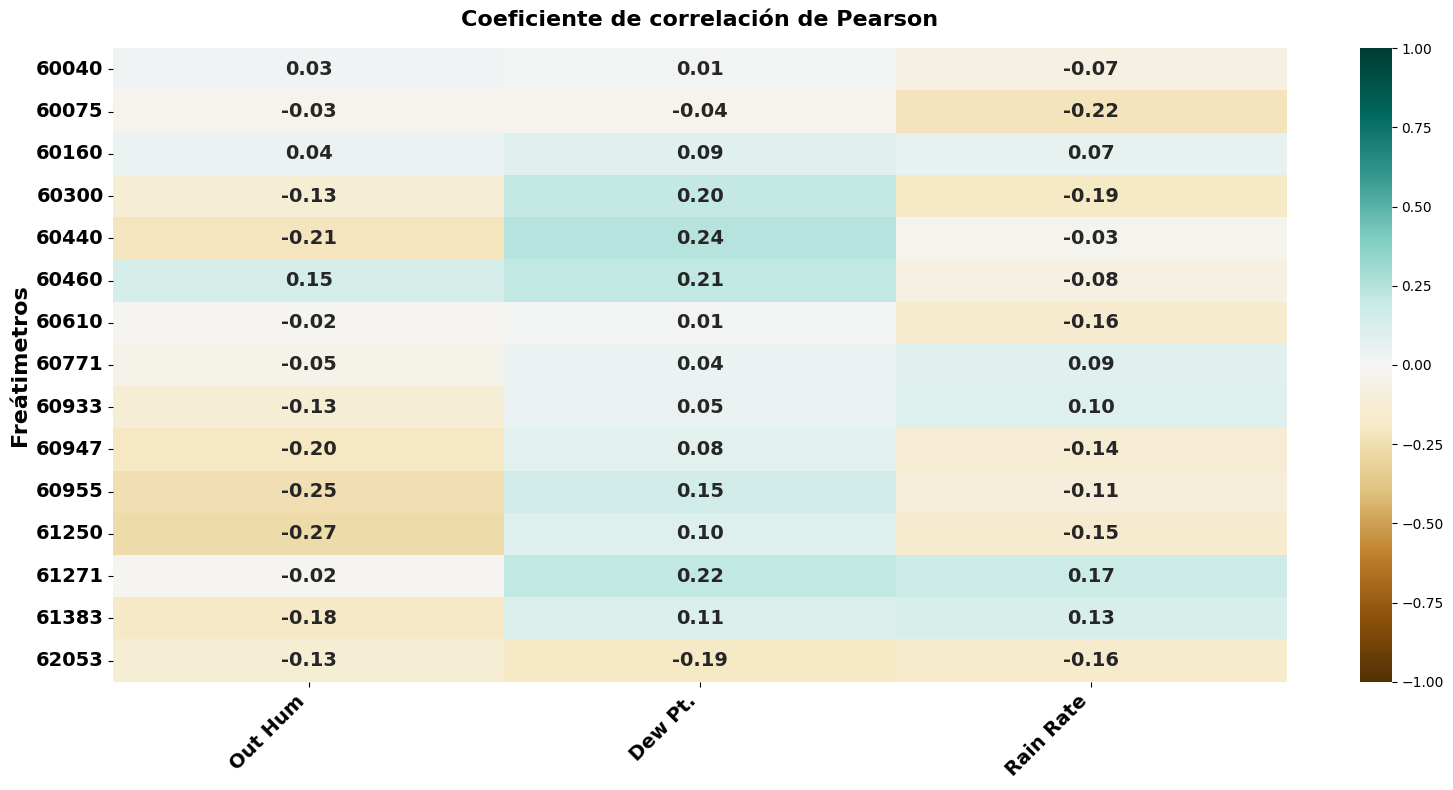

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aux = clima_caso2_h3[columnas_interes].corr(method='pearson')

# Filtrar las columnas y filas existentes en el DataFrame de correlación
freatimetros_labels = [f for f in freatimetros if f in aux.index]
climaticas_labels = [v for v in variables_interes if v in aux.columns]

# Filtrar filas y columnas específicas
filtered_aux = aux.loc[freatimetros_labels, climaticas_labels]

# Contar cuántos freátimetros tienen correlaciones que superen 0.15 (positivo o negativo) por variable climática
variables_to_keep = filtered_aux.apply(lambda x: (abs(x) >= 0.00).sum(), axis=0)
variables_to_keep = variables_to_keep[variables_to_keep > 1].index  # Variables que cumplen la condición



# Filtrar la matriz para las variables climáticas seleccionadas
filtered_aux = filtered_aux[variables_to_keep]

# Crear el heatmap
plt.figure(figsize=(16, 8))
heatmap = sns.heatmap(
    filtered_aux,  # Matriz filtrada
    vmin=-1, vmax=1, annot=True, fmt=".2f", cmap='BrBG',
    annot_kws={"size": 14, "weight": "bold"}  # Tamaño y negrita de los números
)

# Configurar título y etiquetas
heatmap.set_title('Coeficiente de correlación de Pearson',
                  fontdict={'fontsize': 16, "weight": "bold"}, pad=16)
heatmap.set_ylabel('Freátimetros', fontsize=16, weight='bold')

# Rotar las etiquetas del eje X para mayor claridad
plt.xticks(rotation=45, ha='right', fontsize=14, weight='bold')
plt.yticks(fontsize=14, weight='bold')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()